In [1]:
import torch
import dataloader as pi_loader

from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
import torch.nn.functional as F
from torchvision import transforms
from typing import Any, Dict, List

from network import PiVisionNet
from loss import ExistDistCosSinLoss

import os, re
from collections import deque
from torch.utils.tensorboard import SummaryWriter
from torchvision.utils import make_grid
from tqdm import tqdm
from glob import glob
import math
import time

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_folder = ['/home/lab/Documents/picar/2025_train_data/2025_0813_1543-S1',
               '/home/lab/Documents/picar/2025_train_data/2025_0813_1543-S2',
               '/home/lab/Documents/picar/2025_train_data/2025_0813_1543-S3']

data_folder = ['/home/lab/Documents/picar/2025_train_data/2025_0821_1457-S2',
               '/home/lab/Documents/picar/2025_train_data/2025_0821_1457-S1',
               '/home/lab/Documents/picar/2025_train_data/2025_0821_1457-S3',
               '/home/lab/Documents/picar/2025_train_data/2025_0821_1457-S5']

# data_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S1',
#                 '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S2',
#                 '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S3',
#                 '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S4',
#                 '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S5',
#                 '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S7',]

# --- transforms (adjust size to your backbone) ---
# IMG_SIZE = (256, 256)

IMG_SIZE = (128, 128)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=(1.0, 1.5)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- dataset construction ---
# IMPORTANT: set your paths and timestamp column names if different
dataset = pi_loader.PiCarDataset(
    roots=data_folder,
    csv_glob="*.csv",
    transform=train_transform,          # we’ll override for val subset below
    target_transform=None,              # you can plug one in if needed
    strict=False,
    keep_last_n_levels=2, 
    max_time_diff=None,                 # e.g., 0.050 for 50 ms tolerance
    train=True,
    oob_threshold=(-35, 35)
)

# --- train/val split ---
# val_fraction = 0.1
val_fraction = 0.2
n_total = len(dataset)
n_val = max(1, int(n_total * val_fraction))
n_train = n_total - n_val

g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=g)

# give val subset a different (non-augmenting) transform
# random_split returns Subset; override its dataset transform via a wrapper
# Simple approach: set attribute on the base dataset during loaders creation.
# We'll pass a transform override via lambda in the DataLoader collate if needed,
# but easier: duplicate the dataset object for val with same samples.

# Create a lightweight twin dataset that shares the built samples
val_dataset = pi_loader.PiCarDataset(
    roots=[],  # we won't rebuild; we copy state below
    train=False,
    oob_threshold=(-35, 35)
)
# share internal state
val_dataset.samples = dataset.samples
val_dataset.transform = val_transform
val_dataset.target_transform = dataset.target_transform
val_dataset.__len__ = dataset.__len__
val_dataset.__getitem__ = dataset.__getitem__

# Re-wrap the same indices for validation

val_ds = Subset(val_dataset, val_ds.indices)

# --- DataLoaders ---
num_workers = 4
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
    # collate_fn=smart_collate,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
    # collate_fn=smart_collate,
    drop_last=False
)

# --- usage example ---
# for x, y in train_loader:
#     # x: [B, 3, H, W]
#     # y['label_tensor']: [B, N_agents, 3] if present (dist, angle, conf)
#     # y['image_timestamp'], y['pose_stamp']: [B]
#     pass

print(f"Train size: {len(train_ds)}, Test size: {len(val_ds)}")

Train size: 9498, Test size: 2374


In [12]:
import math

def wrap180(angle_deg: float) -> float:
    """Wrap angle to (-180, 180]."""
    return (angle_deg + 180) % 360 - 180

def compute_relative_angles(data: dict):
    """
    Compute angles of each agent relative to 'self' and relative facing direction.
    
    Args:
        data: dict containing self and agent poses
              keys like 'self_pose_x', 'self_pose_y', 'self_pose_angle',
              'car_S2_pose_x', 'car_S2_pose_y', 'car_S2_pose_angle', etc.
    
    Returns:
        dict of results for each agent
    """
    results = {}
    
    # self position and heading
    sx, sy, sa = data["self_pose_x"], data["self_pose_y"], data["self_pose_angle"]
    
    for key in data:
        if key.startswith("car_") and key.endswith("_pose_x"):
            agent = key.split("_pose_x")[0]  # e.g., 'car_S2'
            
            ax = data[f"{agent}_pose_x"]
            ay = data[f"{agent}_pose_y"]
            aa = data[f"{agent}_pose_angle"]
            
            # vector from self → agent
            dx, dy = ax - sx, ay - sy
            angle_to_agent = math.degrees(math.atan2(dy, dx))
            
            # relative angle from self's head
            angle_from_self_head = wrap180(angle_to_agent - sa)
            
            # vector from agent → self
            dx2, dy2 = sx - ax, sy - ay
            angle_to_self = math.degrees(math.atan2(dy2, dx2))
            
            # relative face angle of agent toward self
            relative_face_to_self = wrap180(angle_to_self - aa)
            
            results[agent] = {
                "angle_from_self_head": angle_from_self_head,
                "relative_face_to_self": relative_face_to_self
            }
    
    return results

def compute_head_rel_xy_angle(data: Dict[str, Any], head_offset: float = 70.0) -> Dict[str, Dict[str, float]]:
    """
    Compute (dx, dy) of other agents' head tips relative to self's head tip,
    and the relative angle of those head tips w.r.t. self's head direction.

    Conventions:
      - Angles are in degrees, wrapped to (-180, 180].
      - dx, dy are coordinates of (agent_head - self_head) in the global frame.
      - angle_deg is: angle_between(self_head -> agent_head line and self's head direction).
        0° = straight ahead of self; +CCW, -CW.

    Args:
        data: dict with keys like:
              'self_pose_x', 'self_pose_y', 'self_pose_angle',
              and for agents: 'car_*_pose_x', 'car_*_pose_y', 'car_*_pose_angle'
        head_offset: distance from pose (x, y) to head tip along heading.

    Returns:
        Dict[agent, {'dx': float, 'dy': float, 'angle_deg': float}]
    """
    # Self head tip
    sx, sy, sa = float(data["self_pose_x"]), float(data["self_pose_y"]), float(data["self_pose_angle"])
    sa_rad = math.radians(sa)
    self_head_x = sx + head_offset * math.cos(sa_rad)
    self_head_y = sy + head_offset * math.sin(sa_rad)

    results: Dict[str, Dict[str, float]] = {}

    for key in data:
        if key.startswith("car_") and key.endswith("_pose_x"):
            agent = key[: -len("_pose_x")]  # e.g., 'car_S2'
            ax = float(data[f"{agent}_pose_x"])
            ay = float(data[f"{agent}_pose_y"])
            aa = float(data[f"{agent}_pose_angle"])

            # Agent head tip in global coords
            aa_rad = math.radians(aa)
            agent_head_x = ax + head_offset * math.cos(aa_rad)
            agent_head_y = ay + head_offset * math.sin(aa_rad)

            # Relative vector from self head -> agent head (global frame)
            dx = agent_head_x - self_head_x
            dy = agent_head_y - self_head_y
            
            dx_local =  dx * math.cos(-sa_rad) - dy * math.sin(-sa_rad)
            dy_local =  dx * math.sin(-sa_rad) + dy * math.cos(-sa_rad)

            # angle to +x axis (self's forward)
            angle_local = wrap180(math.degrees(math.atan2(dy_local, dx_local)))

            # Angle of that vector relative to self's head direction
            # angle_global = math.degrees(math.atan2(dy, dx))
            # angle_rel = wrap180(angle_global - sa)

            results[agent] = {
                "dx": dx_local,
                "dy": dy_local,
                "angle_deg": angle_local,
            }

    return results

def compute_head_rel_local_with_blocking(data: dict, head_offset: float = 50.0, angle_thresh: float = 5.0):
    """
    Compute other agents' head positions relative to self's head in self-head local coordinates.
    Add 'blocked' flag when an agent is behind another within angle_thresh.
    
    Returns:
        dict[agent] = {
            'dx_local': float,
            'dy_local': float,
            'angle_deg': float,  # relative to +x axis (self's head forward)
            'dist': float,       # distance from self's head
            'blocked': int       # 1 if occluded by another agent, else 0
        }
    """
    sx, sy, sa = float(data["self_pose_x"]), float(data["self_pose_y"]), float(data["self_pose_angle"])
    sa_rad = math.radians(sa)

    # self head tip
    self_head_x = sx + head_offset * math.cos(sa_rad)
    self_head_y = sy + head_offset * math.sin(sa_rad)

    results = {}

    # --- First compute dx, dy, angle, dist ---
    for key in data:
        if key.startswith("car_") and key.endswith("_pose_x"):
            agent = key[: -len("_pose_x")]
            ax = float(data[f"{agent}_pose_x"])
            ay = float(data[f"{agent}_pose_y"])
            aa = float(data[f"{agent}_pose_angle"])

            # agent head global
            aa_rad = math.radians(aa)
            agent_head_x = ax + head_offset * math.cos(aa_rad)
            agent_head_y = ay + head_offset * math.sin(aa_rad)

            # global diff
            dx = agent_head_x - self_head_x
            dy = agent_head_y - self_head_y

            # rotate into self's local frame
            dx_local =  dx * math.cos(-sa_rad) - dy * math.sin(-sa_rad)
            dy_local =  dx * math.sin(-sa_rad) + dy * math.cos(-sa_rad)

            # angle and distance in local frame
            angle_local = wrap180(math.degrees(math.atan2(dy_local, dx_local)))
            dist = math.hypot(dx_local, dy_local)

            results[agent] = {
                "dx_local": dx_local,
                "dy_local": dy_local,
                "angle_deg": angle_local,
                "dist": dist,
                "blocked": 0  # initialize
            }

    # --- Now check blocking condition ---
    agents = list(results.keys())
    for i in range(len(agents)):
        for j in range(len(agents)):
            if i == j:
                continue
            ai, aj = agents[i], agents[j]
            ang_diff = wrap180(results[ai]["angle_deg"] - results[aj]["angle_deg"])
            if abs(ang_diff) < angle_thresh:
                # if ai is farther, mark as blocked
                if results[ai]["dist"] > results[aj]["dist"]:
                    results[ai]["blocked"] = 1

    return results



Image tensor shape: torch.Size([3, 128, 128])
Label:
{'car_S1_pose_x': 804.7271118164062, 'car_S1_pose_y': 198.22210693359375, 'car_S1_pose_angle': -0.4840329885482788, 'car_S2_pose_x': -294.4520568847656, 'car_S2_pose_y': 955.3707275390625, 'car_S2_pose_angle': -78.77159881591797, 'self_pose_x': 224.73960876464844, 'self_pose_y': -490.627685546875, 'self_pose_angle': -151.7738494873047, 'car_S4_pose_x': -1149.4462890625, 'car_S4_pose_y': -887.6085205078125, 'car_S4_pose_angle': 35.908504486083984, 'car_S5_pose_x': -894.0113525390625, 'car_S5_pose_y': -139.95034790039062, 'car_S5_pose_angle': 148.39639282226562, 'ts': 1.7557807595181676e+18, 'pose_timestamp': 1.7557807595181676e+18, 'image_timestamp': 1.755780759516245e+18, 'path': '/home/lab/Documents/picar/2025_train_data/2025_0821_1457-S3/20250821/image_1755780759516244976.png', 'label_tensor': tensor([[-9.3067e+02, -3.0861e+02,  0.0000e+00],
        [-2.6182e+02, -1.4718e+03,  0.0000e+00],
        [ 1.2990e+03, -3.0683e+02,  1.0000

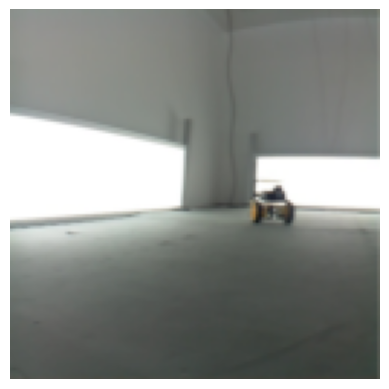

tensor([[ 1.2988e+03, -3.0731e+02,  9.9438e-01]])


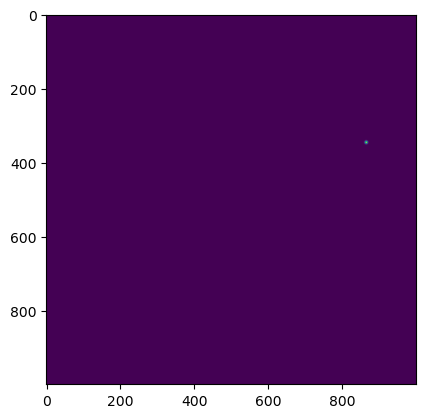

In [16]:
import shutil
from utils import points_to_heatmap, heatmap_to_points

image_id = 69
img_tensor, label = val_ds[image_id]  # applies transform automatically
print("Image tensor shape:", img_tensor.shape)
print("Label:")
# for i in range(2):
#     # print(f"dist: {label[i,0]}, angle: {torch.atan2(label[i,2], label[i,1]) * 180.0 / math.pi}, existance: {label[i,3]}")
#     print(f"x: {label[i,0]}, y: {label[i,1]}, existance: {label[i,2]}")

# Denormalize if using ImageNet normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_vis = img_tensor * std + mean
img_vis = torch.clamp(img_vis, 0, 1)

print(f"{label}")
print(f"{label['label_tensor']}")
angle_result = compute_head_rel_local_with_blocking(label)
for k in angle_result.keys():
    print(f"{k}: {angle_result[k]}")

plt.imshow(img_vis.permute(1, 2, 0))  # CHW -> HWC
plt.axis("off")
plt.show()

# shutil.copy(label['path'], os.path.join('/home/lab/Documents/picar/picar_ros2/training/eval', f'image_{image_id}_original.png'))
coord_range=((0.0, 1500.0), (-1000.0, 1000.0))
heatmap = points_to_heatmap(label['label_tensor'], coord_range=coord_range, heatmap_size=(1000, 1000))
print(heatmap_to_points(heatmap, coord_range=coord_range))
plt.imshow(heatmap)

In [4]:
# use during inference 
with torch.no_grad():
    pred = model(imgs)                           # [B,2,4]
    z_dist, z_cos, z_sin, z_exist = pred.unbind(dim=-1)
    prob_exist = torch.sigmoid(z_exist)          # [B,2]
    present = prob_exist > 0.5

    # distance (positive)
    dist = torch.nn.functional.softplus(z_dist)

    # normalize direction
    vec = torch.stack([z_cos, z_sin], dim=-1)
    unit = vec / (vec.norm(dim=-1, keepdim=True) + 1e-8)
    cosv, sinv = unit[..., 0], unit[..., 1]

    # (optional) recover angle degrees for reporting
    angle_deg = torch.atan2(sinv, cosv) * 180.0 / 3.1415926535

NameError: name 'model' is not defined

In [6]:
def save_ckpt(path, model, optimizer, epoch, best_val=None, scheduler=None, extra=None):
    ckpt = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,                 # 1-based epoch index
        "best_val": best_val,
    }
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    if extra is not None:
        ckpt["extra"] = extra
    torch.save(ckpt, path)

def load_ckpt(path, model, optimizer=None, scheduler=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model"])
    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    if scheduler is not None and "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch = ckpt.get("epoch", 0)          # resume from next epoch
    best_val = ckpt.get("best_val", float("inf"))
    extra = ckpt.get("extra", None)
    return start_epoch + 1, best_val, extra     # next_epoch, best_val, extra

def latest_epoch_ckpt(save_dir):
    paths = glob(os.path.join(save_dir, "epoch_*.ckpt"))
    if not paths: return None
    def ep(path):
        m = re.search(r"epoch_(\d+)\.ckpt$", path)
        return int(m.group(1)) if m else -1
    return max(paths, key=ep)


def train_with_resume(
    model, criterion, optimizer, train_loader, val_loader=None,
    epochs=10, device="cuda", log_dir="runs/exp1", scheduler=None,
    log_images_every=200, save_dir="checkpoints", keep_last=5,
    resume_from=None, auto_resume_latest=False
):
    os.makedirs(save_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=log_dir)
    model.to(device)

    # ---- Resume logic ----
    if resume_from is None and auto_resume_latest:
        resume_from = latest_epoch_ckpt(save_dir)
    if resume_from:
        start_epoch, best_val_loss, _ = load_ckpt(
            resume_from, model, optimizer, scheduler, map_location="cpu"
        )
        print(f"Resumed from {resume_from} -> start_epoch={start_epoch}, best_val={best_val_loss:.6f}")
    else:
        start_epoch, best_val_loss = 1, float("inf")

    recent_ckpts = deque(maxlen=keep_last)
    # pre-fill deque with existing recent ckpts if resuming
    for p in sorted(glob(os.path.join(save_dir, "epoch_*.ckpt"))):
        recent_ckpts.append(p)

    global_step = 0

    for epoch in range(start_epoch, epochs + 1):
        # ---------------- Train ----------------
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"Train {epoch}/{epochs}", unit="batch")
        for step, (imgs, labels) in enumerate(pbar, 1):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            preds = model(imgs)
            loss = criterion(preds, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            if scheduler and getattr(scheduler, "_step_every_batch", False):
                scheduler.step()  # for per-step schedulers like OneCycle; set this flag yourself

            running += loss.item()
            avg_loss = running / step
            writer.add_scalar("train/loss_step", loss.item(), global_step)

            if log_images_every and (global_step % log_images_every == 0):
                mean = torch.tensor([0.485, 0.456, 0.406], device=imgs.device).view(1,3,1,1)
                std  = torch.tensor([0.229, 0.224, 0.225], device=imgs.device).view(1,3,1,1)
                vis = torch.clamp(imgs[:16] * std + mean, 0, 1)
                writer.add_image("train/images", make_grid(vis, nrow=4), global_step)

            pbar.set_postfix({"loss": f"{avg_loss:.4f}"})
            global_step += 1

        train_loss_epoch = running / max(1, len(train_loader))
        writer.add_scalar("train/loss_epoch", train_loss_epoch, epoch)

        if scheduler and not getattr(scheduler, "_step_every_batch", False):
            scheduler.step()  # per-epoch schedulers

        # ---------------- Validate ----------------
        val_loss_epoch = None
        if val_loader is not None:
            model.eval()
            val_running = 0.0
            with torch.no_grad():
                for imgs, labels in tqdm(val_loader, desc=f"Val   {epoch}/{epochs}", unit="batch"):
                    imgs = imgs.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    preds = model(imgs)
                    val_loss = criterion(preds, labels)
                    val_running += val_loss.item()
            val_loss_epoch = val_running / max(1, len(val_loader))
            writer.add_scalar("val/loss_epoch", val_loss_epoch, epoch)

            # ---- save best ----
            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_path = os.path.join(save_dir, "best.ckpt")
                save_ckpt(best_path, model, optimizer, epoch, best_val=best_val_loss, scheduler=scheduler)
                print(f"✅ Saved BEST: {best_path} (val={best_val_loss:.6f})")

        # ---- save last N ----
        ckpt_path = os.path.join(save_dir, f"epoch_{epoch}.ckpt")
        save_ckpt(ckpt_path, model, optimizer, epoch, best_val=best_val_loss, scheduler=scheduler)
        recent_ckpts.append(ckpt_path)
        # prune older than keep_last
        while len(recent_ckpts) > keep_last:
            old = recent_ckpts.popleft()
            if os.path.exists(old):
                os.remove(old)

        print(f"Epoch {epoch}: train={train_loss_epoch:.4f}" +
              (f", val={val_loss_epoch:.4f}" if val_loss_epoch is not None else ""))

    writer.close()

def train_with_tb(
    model, criterion, optimizer, train_loader, val_loader=None,
    epochs=10, device="cuda", log_dir="runs/exp1", scheduler=None,
    log_images_every=200, save_dir="checkpoints", keep_last=5
):
    os.makedirs(save_dir, exist_ok=True)
    from torch.utils.tensorboard import SummaryWriter
    from torchvision.utils import make_grid
    from tqdm import tqdm

    writer = SummaryWriter(log_dir=log_dir)
    model.to(device)

    best_val_loss = float("inf")
    recent_ckpts = deque(maxlen=keep_last)  # track last N checkpoints
    global_step = 0

    for epoch in range(1, epochs + 1):
        # ---------------- Train ----------------
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"Train {epoch}/{epochs}", unit="batch")

        for step, (imgs, labels) in enumerate(pbar, 1):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            preds = model(imgs)
            loss = criterion(preds, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running += loss.item()
            avg_loss = running / step
            writer.add_scalar("train/loss_step", loss.item(), global_step)

            # Optional: log images
            if log_images_every and (global_step % log_images_every == 0):
                mean = torch.tensor([0.485, 0.456, 0.406], device=imgs.device).view(1,3,1,1)
                std  = torch.tensor([0.229, 0.224, 0.225], device=imgs.device).view(1,3,1,1)
                vis = torch.clamp(imgs[:16] * std + mean, 0, 1)
                grid = make_grid(vis, nrow=4)
                writer.add_image("train/images", grid, global_step)

            pbar.set_postfix({"loss": f"{avg_loss:.4f}"})
            global_step += 1

        train_loss_epoch = running / max(1, len(train_loader))
        writer.add_scalar("train/loss_epoch", train_loss_epoch, epoch)

        if scheduler is not None:
            scheduler.step()

        # ---------------- Validate ----------------
        val_loss_epoch = None
        if val_loader is not None:
            model.eval()
            val_running = 0.0
            with torch.no_grad():
                for imgs, labels in tqdm(val_loader, desc=f"Val   {epoch}/{epochs}", unit="batch"):
                    imgs = imgs.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    preds = model(imgs)
                    val_loss = criterion(preds, labels)
                    val_running += val_loss.item()

            val_loss_epoch = val_running / max(1, len(val_loader))
            writer.add_scalar("val/loss_epoch", val_loss_epoch, epoch)

            # --- Save best ---
            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_path = os.path.join(save_dir, "best.pth")
                torch.save(model.state_dict(), best_path)
                print(f"✅ Saved best model: {best_path} (val_loss={best_val_loss:.4f})")

        # --- Save last N checkpoints ---
        ckpt_path = os.path.join(save_dir, f"epoch_{epoch}.pth")
        torch.save(model.state_dict(), ckpt_path)
        recent_ckpts.append(ckpt_path)

        # Remove oldest if exceeding keep_last
        while len(recent_ckpts) > keep_last:
            old_ckpt = recent_ckpts.popleft()
            if os.path.exists(old_ckpt):
                os.remove(old_ckpt)

        # Print epoch summary
        print(f"Epoch {epoch}: train_loss={train_loss_epoch:.4f}"
              + (f", val_loss={val_loss_epoch:.4f}" if val_loss_epoch is not None else ""))

    writer.close()

In [4]:
model = PiVisionNet(backbone_name="resnet18", pretrained=True, out_agents=4)  
criterion = ExistDistCosSinLoss(w_exist=1.0, w_dist=1.0, w_dir=1.0)        
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# optional scheduler example
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# train_with_tb(model, criterion, optimizer, train_loader, val_loader,
#               epochs=100, device="cuda", log_dir="/home/lab/Documents/picar/2025_train_data/runs/picar", scheduler=scheduler)

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
train_with_resume(
    model, criterion, optimizer, train_loader, val_loader,
    epochs=100, device="cuda", log_dir="/home/lab/Documents/picar/2025_train_data/runs/picar", save_dir="checkpoints",
    scheduler=scheduler, keep_last=5, resume_from="checkpoints/epoch_40.ckpt"
)

Resumed from checkpoints/epoch_40.ckpt -> start_epoch=41, best_val=81.591811


Val   41/100: 100%|██████████| 37/37 [00:01<00:00, 19.83batch/s]


✅ Saved BEST: checkpoints/best.ckpt (val=68.511488)
Epoch 41: train=63.5379, val=68.5115


Train 42/100:  57%|█████▋    | 187/329 [00:08<00:06, 21.72batch/s, loss=54.7207]


KeyboardInterrupt: 

In [807]:
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple

def load_model_from_ckpt(ckpt_path, backbone="resnet18", out_agents=2, device="cuda"):
    model = PiVisionNet(backbone_name=backbone, pretrained=False, out_agents=out_agents)
    ckpt = torch.load(ckpt_path, map_location="cpu")

    # two formats supported:
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state, strict=True)

    model.to(device).eval()
    return model


def postprocess_head4(out_4, exist_thresh=0.5):  # out_4: [B,2,4]
    z_dist, z_cos, z_sin, z_exist = out_4.unbind(dim=-1)
    dist = F.softplus(z_dist)

    vec = torch.stack([z_cos, z_sin], dim=-1)
    unit = vec / (vec.norm(dim=-1, keepdim=True) + 1e-8)
    cosv, sinv = unit[...,0], unit[...,1]
    angle_deg = torch.atan2(sinv, cosv) * 180.0 / math.pi

    prob_exist = torch.sigmoid(z_exist)                                 # [B,2]
    present = (prob_exist > exist_thresh)

    return dist, cosv, sinv, angle_deg, prob_exist, present

# def postprocess_head3(out_3, exist_thresh=0.5):  # out_4: [B,2,4]
#     z_dist, z_cos, z_sin, z_exist = out_4.unbind(dim=-1)
#     dist = F.softplus(z_dist)

#     vec = torch.stack([z_cos, z_sin], dim=-1)
#     unit = vec / (vec.norm(dim=-1, keepdim=True) + 1e-8)
#     cosv, sinv = unit[...,0], unit[...,1]
#     angle_deg = torch.atan2(sinv, cosv) * 180.0 / math.pi

#     prob_exist = torch.sigmoid(z_exist)                                 # [B,2]
#     present = (prob_exist > exist_thresh)

#     return dist, cosv, sinv, angle_deg, prob_exist, present

def wrap_deg(d):
    # wrap to [-180, 180)
    return (d + 180.0) % 360.0 - 180.0

def metrics_xy_to_posY(x_label, y_label, x_pred, y_pred):
    """
    Inputs: tensors or floats, broadcastable shapes.
    Returns: dict with tensors (same broadcasted shape).
    """
    x_label = torch.as_tensor(x_label, dtype=torch.float32)
    y_label = torch.as_tensor(y_label, dtype=torch.float32)
    x_pred  = torch.as_tensor(x_pred,  dtype=torch.float32)
    y_pred  = torch.as_tensor(y_pred,  dtype=torch.float32)

    # deltas
    dx = x_pred - x_label
    dy = y_pred - y_label

    # distances
    L1 = dx.abs() + dy.abs()
    L2 = torch.hypot(dx, dy)  # sqrt(dx^2 + dy^2), stable

    # angle to +Y axis:
    # standard atan2(y, x) is angle from +X; to measure from +Y use atan2(x, y).
    theta_label_rad = torch.atan2(x_label, y_label)
    theta_pred_rad  = torch.atan2(x_pred,  y_pred)

    # degrees
    theta_label_deg = theta_label_rad * (180.0 / math.pi)
    theta_pred_deg  = theta_pred_rad  * (180.0 / math.pi)

    # wrapped angle difference (pred - label) in [-180, 180)
    angle_diff_deg = wrap_deg(theta_pred_deg - theta_label_deg)

    return {
        "L1": L1,
        "L2": L2,
        "theta_label_deg_from_posY": theta_label_deg,
        "theta_pred_deg_from_posY": theta_pred_deg,
        "angle_diff_deg": angle_diff_deg,
    }

def _angle_from_posY(x, y):
    # angle (deg) measured from +Y axis, CCW positive
    #return torch.atan2(x, y) * (180.0 / math.pi)
    # manual adjust axis
    return torch.atan2(y, x) * (180.0 / math.pi)

def _wrap_deg(d):
    return (d + 180.0) % 360.0 - 180.0

def filter_by_conf_and_visibility(
    rel_xyc: torch.Tensor,
    conf_thresh: float = 0.5,
    angle_thresh_deg: float = 2.0,
    eps: float = 1e-6,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Filter detections by confidence and non-blocking visibility.

    Input:
        rel_xyc: Tensor of shape (N, 3), each row = [x, y, conf]
                 x,y are relative coordinates in self-head local frame
                 (+x forward, +y left). Units arbitrary but consistent.
        conf_thresh: keep only rows with conf > conf_thresh
        angle_thresh_deg: two agents considered collinear if their
                          angle difference is within this tolerance (degrees)
        eps: small number to break distance ties

    Output:
        filtered: Tensor of rows that pass both filters
        keep_mask: Boolean mask of shape (N,) indicating kept rows

    Blocking rule:
        A detection i is marked blocked if there exists another detection j
        such that:
            - conf_j > conf_thresh
            - |angle_i - angle_j| <= angle_thresh
            - dist_i > dist_j - eps   (i is strictly farther than j)
        Blocked rows are removed.
    """
    assert rel_xyc.dim() == 2 and rel_xyc.size(1) == 3, "Expected (N,3) tensor [x,y,conf]."
    if rel_xyc.numel() == 0:
        return rel_xyc, torch.zeros((0,), dtype=torch.bool, device=rel_xyc.device)

    x = rel_xyc[:, 0]
    y = rel_xyc[:, 1]
    conf = rel_xyc[:, 2]

    # 1) Confidence mask
    conf_mask = conf > conf_thresh
    if conf_mask.sum() <= 1:
        # Zero or one confident detection: nothing can block it
        keep_mask = conf_mask.clone()
        return rel_xyc[keep_mask], keep_mask

    # Polar quantities
    angles = torch.atan2(y, x)                     # radians in (-pi, pi]
    dists = torch.hypot(x, y)                      # distance >= 0
    angle_thresh = angle_thresh_deg * torch.pi / 180.0

    # Pairwise angle differences wrapped to (-pi, pi]
    # diff[i,j] = angle_i - angle_j (wrapped)
    diff = angles[:, None] - angles[None, :]
    diff = (diff + torch.pi) % (2 * torch.pi) - torch.pi
    angle_close = torch.abs(diff) <= angle_thresh  # (N, N) bool

    # Pairwise distance comparison: is i farther than j?
    farther = dists[:, None] > (dists[None, :] - eps)  # (N, N) bool

    # Only confident j can block; ignore self-comparison on diagonal
    conf_j = conf_mask[None, :].expand_as(angle_close)
    not_self = ~torch.eye(len(rel_xyc), dtype=torch.bool, device=rel_xyc.device)

    # i is blocked if exists j: angle_close & farther & conf_j & not_self
    blocked_matrix = angle_close & farther & conf_j & not_self
    blocked = blocked_matrix.any(dim=1)

    # Keep: confident and not blocked
    keep_mask = conf_mask & (~blocked)
    filtered = rel_xyc[keep_mask]
    return filtered, keep_mask

@torch.no_grad()
def hungarian_match_and_metrics(
    pred: torch.Tensor,      # [N,3] (x, y, conf)
    target: torch.Tensor,    # [N,3] (x, y, conf)
    conf_thresh: float = 0.5,
    cost_type: str = "l2",
    weight_cost_by_conf: bool = True,
    aggregate_weighted: bool = True,
    pos_scale: float = 1.0,
):
    """
    Match pred ↔ target with Hungarian algo after filtering out low-confidence rows.
    """
    assert pred.ndim == 2 and target.ndim == 2 and pred.size(1) >= 3 and target.size(1) >= 3
    device = pred.device

    # --- filter out low confidence rows ---
    pred_mask = pred[:, 2] >= conf_thresh
    # target_mask = target[:, 2] >= conf_thresh
    pred = pred[pred_mask]
    # target = target[target_mask]
    target, target_mask = filter_by_conf_and_visibility(target, conf_thresh=0.5, angle_thresh_deg=2.)
    
    # print(torch.sigmoid(pred[:, 2]))
    # print(pred)
    # print(target)

    if pred.numel() == 0 or target.numel() == 0:
        status = 'abnormal'
        if pred.numel() == 0 and target.numel() > 0:
            status = 'false positive'
        elif pred.numel() > 0 and target.numel() == 0:
            status = 'false negative'
        elif pred.numel() == 0 and target.numel() == 0:
            status = 'true negative'
            
        # nothing left after filtering
        return {
            "status": status,
            "masked_pred": pred,
            "masked_target": target,
            "row_ind": torch.empty(0, dtype=torch.long, device=device),
            "col_ind": torch.empty(0, dtype=torch.long, device=device),
            "per_pair": {},
            "mean": {},
        }

    # split
    x_p, y_p = pred[:, 0], pred[:, 1]
    x_t, y_t = target[:, 0], target[:, 1]
    conf_t = target[:, 2]

    Np, Nt = pred.size(0), target.size(0)

    # --- cost matrix ---
    xp = x_p.cpu().numpy()
    yp = y_p.cpu().numpy()
    xt = x_t.cpu().numpy()
    yt = y_t.cpu().numpy()
    wt = conf_t.cpu().numpy() if weight_cost_by_conf else np.ones_like(xt)

    C = np.zeros((Np, Nt), dtype=np.float64)
    if cost_type == "l2":
        for i in range(Np):
            dx = xp[i] - xt
            dy = yp[i] - yt
            C[i, :] = np.sqrt(dx * dx + dy * dy) * wt * pos_scale
    else:  # l1
        for i in range(Np):
            C[i, :] = (np.abs(xp[i] - xt) + np.abs(yp[i] - yt)) * wt * pos_scale

    row_ind, col_ind = linear_sum_assignment(C)
    row_ind_t = torch.as_tensor(row_ind, device=device, dtype=torch.long)
    col_ind_t = torch.as_tensor(col_ind, device=device, dtype=torch.long)

    # gather matched
    xph = x_p[row_ind_t]
    yph = y_p[row_ind_t]
    xth = x_t[col_ind_t]
    yth = y_t[col_ind_t]
    w_match = conf_t[col_ind_t] if aggregate_weighted else torch.ones_like(xph)

    dx = xph - xth
    dy = yph - yth
    L1 = dx.abs() + dy.abs()
    L2 = torch.hypot(dx, dy)

    theta_pred = _angle_from_posY(xph, yph)
    theta_tgt = _angle_from_posY(xth, yth)
    angle_diff = _wrap_deg(theta_pred - theta_tgt)

    wsum = torch.clamp(w_match.sum(), min=1e-8)
    mean_L1 = (w_match * L1).sum() / wsum
    mean_L2 = (w_match * L2).sum() / wsum
    mean_ang = (w_match * np.abs(angle_diff)).sum() / wsum

    return {
        "status": 'true positive',
        "masked_pred": pred,
        "masked_target": target,
        "row_ind": row_ind_t,
        "col_ind": col_ind_t,
        "per_pair": {
            "L1": L1,
            "L2": L2,
            "theta_pred_deg": theta_pred,
            "theta_target_deg": theta_tgt,
            "angle_diff_deg": angle_diff,
            "weight": w_match,
        },
        "mean": {
            "L1": mean_L1,
            "L2": mean_L2,
            "angle_diff_deg": mean_ang,
        }
    }


def get_colors(n, cmap_name="tab10"):
    cmap = plt.get_cmap(cmap_name)   # e.g. "tab10", "tab20", "viridis", "plasma"
    return [cmap(i / max(1, n-1)) for i in range(n)]  # evenly spaced

def _ray_endpoint_to_axes(ax, x0, y0, angle_deg):
    """
    From (x0,y0), cast a ray at angle_deg and return its intersection with ax's
    current rectangular limits. Returns (x1, y1).
    """
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    th = math.radians(angle_deg)
    c, s = math.cos(th), math.sin(th)

    # Parametric ray: x = x0 + t*c, y = y0 + t*s, t >= 0
    candidates = []

    # Intersect with verticals x = xmin/xmax
    if abs(c) > 1e-12:
        t = (xmin - x0) / c
        if t >= 0:
            y = y0 + t*s
            if ymin - 1e-9 <= y <= ymax + 1e-9:
                candidates.append((t, xmin, y))
        t = (xmax - x0) / c
        if t >= 0:
            y = y0 + t*s
            if ymin - 1e-9 <= y <= ymax + 1e-9:
                candidates.append((t, xmax, y))

    # Intersect with horizontals y = ymin/ymax
    if abs(s) > 1e-12:
        t = (ymin - y0) / s
        if t >= 0:
            x = x0 + t*c
            if xmin - 1e-9 <= x <= xmax + 1e-9:
                candidates.append((t, x, ymin))
        t = (ymax - y0) / s
        if t >= 0:
            x = x0 + t*c
            if xmin - 1e-9 <= x <= xmax + 1e-9:
                candidates.append((t, x, ymax))

    if not candidates:
        # Fallback: extend a long segment if something degenerate happens
        L = max(xmax - xmin, ymax - ymin) * 2.0
        return (x0 + L*c, y0 + L*s)

    # Pick the nearest positive intersection
    _, x1, y1 = min(candidates, key=lambda tup: tup[0])
    return x1, y1


def _draw_fov_rays(ax, x0, y0, facing_deg, delta_deg=30.0, **plot_kw):
    """
    Draw two rays from (x0,y0) at facing ± delta_deg to the axes bounds.
    """
    for sign in (+1, -1):
        ang = facing_deg + sign * delta_deg
        x1, y1 = _ray_endpoint_to_axes(ax, x0, y0, ang)
        ax.plot([x0, x1], [y0, y1], **plot_kw)

def plot_pred_vs_target(pred: torch.Tensor,
                        target: torch.Tensor,
                        alpha_target=0.95,
                        alpha_pred=0.65,
                        marker_target="o",
                        marker_pred="x",
                        arrow_scale=1.0,
                        threshold=0.5,
                        title="Predction (X) vs Target (O)",
                        fig_size=(6, 6),
                        dpi=300,
                        save_path=None
                        ):
    """
    pred, target: shape (N, 2) tensors of (x, y)
    """
    assert pred.ndim == 2 and target.ndim == 2 and pred.shape[1] == 2 and target.shape[1] == 2
    # assert pred.shape[0] == target.shape[0], "pred and target must have the same N rows"
    
    # rotate 90 deg
    pred = torch.stack([-pred[..., 1], pred[..., 0]], dim=-1)
    target = torch.stack([-target[..., 1], target[..., 0]], dim=-1)

    # move to CPU numpy
    P = pred.detach().cpu().numpy() / 1000
    T = target.detach().cpu().numpy() / 1000
    Np = P.shape[0]
    Nt = T.shape[0]

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

    colors = get_colors(5, "viridis")
    
    # We’ll pull one color from the cycle per index i, then reuse it for both target and pred.
    for i in range(Nt):
        # get a new color from the current axes’ color cycle
        color = colors[i]

        # target point (more opaque) + arrow
        ax.scatter(T[i, 0], T[i, 1], marker=marker_target, alpha=alpha_target, s=60, color='orange', label=None)
        ax.arrow(0.0, 0.0, T[i, 0], T[i, 1],
                 head_width=0.02 * arrow_scale, head_length=0.04 * arrow_scale,
                 length_includes_head=True, alpha=alpha_target, color='orange')

    for i in range(Np):
        # if P[i,2] < threshold:
        #     continue
        
        # prediction point (more transparent) + arrow (same color)
        ax.scatter(P[i, 0], P[i, 1], marker=marker_pred, alpha=alpha_pred, s=60, color='green', label=None)
        ax.arrow(0.0, 0.0, P[i, 0], P[i, 1],
                 head_width=0.02 * arrow_scale, head_length=0.04 * arrow_scale,
                 length_includes_head=True, alpha=alpha_pred, color='green')
    
    # styling
    ax.axhline(0, lw=0.8, alpha=0.5)
    ax.axvline(0, lw=0.8, alpha=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    # auto limits with some padding
    all_pts = torch.cat([pred, target], dim=0).detach().cpu().numpy()
    if all_pts.size > 0:
        xmin, ymin = all_pts.min(axis=0)
        xmax, ymax = all_pts.max(axis=0)
        # pad_x = 0.05 * max(1e-6, (xmax - xmin))
        # pad_y = 0.05 * max(1e-6, (ymax - ymin))
        pad_x = 0.1
        pad_y = 0.1
        ax.set_xlim(-2.3 - pad_x, 2.3 + pad_x)
        ax.set_ylim(0 - pad_y, 2.3 + pad_y)
        
    _draw_fov_rays(
                ax, 0, 0, 90, delta_deg=30.0,
                linewidth=1.5, linestyle="-.", alpha=0.6, color='red'
            )   
    
    ax.axis("off")

    if save_path:
        print(f'result saved to {save_path}')
        plt.savefig(save_path, dpi=300, bbox_inches="tight") 

    plt.show()

In [6]:
def batch_metric(batch_pred, batch_target):
    assert batch_pred.size(0) == batch_target.size(0)
    batch_num = batch_pred.size(0)
    
    case_count = {"true positive": 0, 
                  "false positive": 0, 
                  "false negative": 0, 
                  "true negative": 0
                  }
    values_sum = {'L1': 0, "L2": 0, "angle": 0}
    values_tensor = {'pred': [], "target": []}
    for i in range(batch_num):
        single_metric = hungarian_match_and_metrics(batch_pred[i], batch_target[i], weight_cost_by_conf=False)
        case_count[single_metric['status']] += 1
        if single_metric['status'] == 'true positive':
            values_sum["L1"] += single_metric['mean']['L1']
            values_sum["L2"] += single_metric['mean']['L2']
            values_sum["angle"] += single_metric['mean']['angle_diff_deg']
            
            # values_tensor["L1"].append(single_metric['per_pair']['L1'])
            # values_tensor["angle"].append(single_metric['per_pair']['angle_diff_deg'])
            # values_tensor["L2"].append(single_metric['per_pair']['L2'])
            
            values_tensor["pred"].append(single_metric['masked_pred'])
            values_tensor["target"].append(single_metric['masked_target'])
            
    return values_sum, values_tensor, case_count
        

In [799]:
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_small.ckpt", backbone="mobilenetv3_small", out_agents=4)
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_large.ckpt", backbone="mobilenetv3_large", out_agents=4)
trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_resnet18.ckpt", backbone="resnet18", out_agents=4)

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [823]:
image_id = 48
plot_output = True

Image tensor shape: torch.Size([3, 128, 128])
raw prediction: tensor([[ 9.3776e+02, -2.0817e+02,  9.2869e-01],
        [ 9.4792e+02,  1.8196e+02,  3.9898e-02],
        [ 1.1893e+03, -1.1805e+02,  1.2087e-02],
        [ 1.4695e+03,  5.6219e+02,  9.9848e-01]])
raw target: tensor([[ 9.1991e+02, -2.0231e+02,  1.0000e+00],
        [ 6.5054e+02, -8.2136e+02,  0.0000e+00],
        [ 2.2259e+03, -3.7136e+02,  0.0000e+00],
        [ 1.5640e+03, -5.3535e+02,  1.0000e+00],
        [ 1.4959e+03,  5.8602e+02,  1.0000e+00],
        [ 1.0975e+03, -7.7155e+02,  0.0000e+00]])
{'status': 'true positive', 'masked_pred': tensor([[ 9.3776e+02, -2.0817e+02,  9.2869e-01],
        [ 1.4695e+03,  5.6219e+02,  9.9848e-01]]), 'masked_target': tensor([[ 9.1991e+02, -2.0231e+02,  1.0000e+00],
        [ 1.5640e+03, -5.3535e+02,  1.0000e+00],
        [ 1.4959e+03,  5.8602e+02,  1.0000e+00]]), 'row_ind': tensor([0, 1]), 'col_ind': tensor([0, 2]), 'per_pair': {'L1': tensor([23.7222, 50.2234]), 'L2': tensor([18.7938, 3

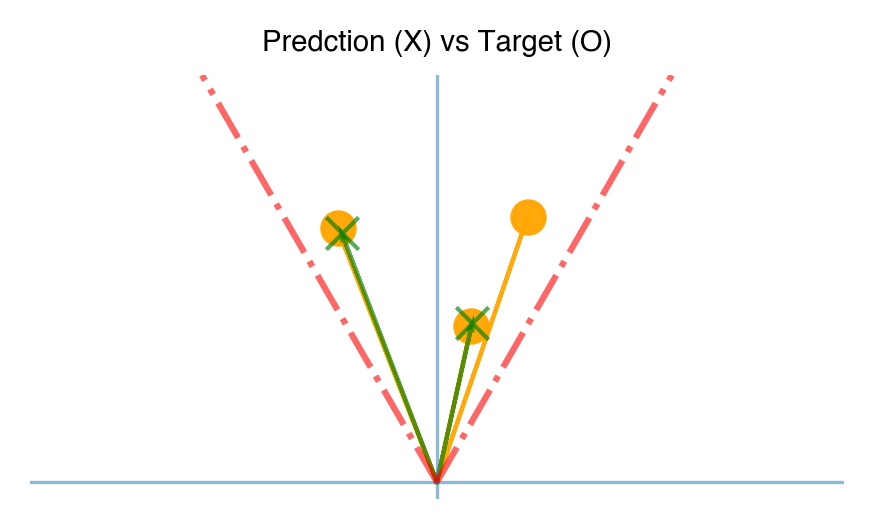

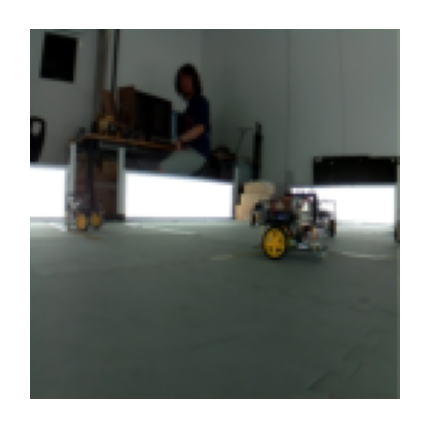

In [824]:
import matplotlib.pyplot as plt
%matplotlib inline

fig_size = (3.5, 2.5)
dpi = 300

img_tensor, label = val_ds[image_id]  # applies transform automatically
label = label.detach().cpu()
print("Image tensor shape:", img_tensor.shape)
# print("Label:")
# for i in range(2):
#     # print(f"dist: {label[i,0]}, angle: {torch.atan2(label[i,2], label[i,1]) * 180.0 / math.pi}, existance: {label[i,3]}")
#     print(f"x: {label[i,0]}, y: {label[i,1]}, existance: {label[i,2]}")

# Denormalize if using ImageNet normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_vis = img_tensor * std + mean
img_vis = torch.clamp(img_vis, 0, 1)

save_path = None

# print("Prediction:")
with torch.no_grad():
    prediction = trained_model(img_tensor.unsqueeze(0).cuda())
    prediction = prediction.squeeze(0).detach().cpu()
    for i in range(prediction.size(0)):
        prediction[i,2] = torch.sigmoid(prediction[i,2])
        
    print(f'raw prediction: {prediction}')
    print(f"raw target: {label}")
    
    # dist, cosv, sinv, angle_deg, prob_exist, present = postprocess_head4(prediction)
    # for i in range(2):
    #     # print(f"dist: {dist[0,i]}, angle: {angle_deg[0,i]}, existance: {prob_exist[0,i]}")
    #     print(f"x: {prediction[i,0]}, y: {prediction[i,1]}, existance: {torch.sigmoid(prediction[i,2])}")
    
    # for i in range(2):
        # print(metrics_xy_to_posY(label[i,0], label[i,1], prediction[i,0], prediction[i,1]))
        
    metrics_result = hungarian_match_and_metrics(prediction, label, weight_cost_by_conf=False, conf_thresh=0.1)
    print(metrics_result)
    m_pred = metrics_result["masked_pred"]
    m_target = metrics_result["masked_target"]
    
    if metrics_result["status"] == 'true positive':
        # for i, j in zip(metrics_result['row_ind'], metrics_result['col_ind']):
        #     print(f"prediction: ({m_pred[i,0]}, {m_pred[i,1]}, {m_pred[i,2]})")
        #     print(f"target: ({m_target[i,0]}, {m_target[i,1]}, {m_target[i,2]})")
            
        # for i in range(m_pred.size(0)):
        #     print(f'L1: {metrics_result["per_pair"]["L1"][i]}, L2: {metrics_result["per_pair"]["L2"][i]}')
        #     print(f'pred_angle: {metrics_result["per_pair"]["theta_pred_deg"][i]}, target_angle: {metrics_result["per_pair"]["theta_target_deg"][i]}, angle_diff: {metrics_result["per_pair"]["angle_diff_deg"][i]}')
            
        print(f"mean metrics")
        print(f'L1: {metrics_result["mean"]["L1"]}, L2: {metrics_result["mean"]["L2"]}, angle: {metrics_result["mean"]["angle_diff_deg"]}')
        l2_error = metrics_result["mean"]["L2"]
        ang_error = metrics_result["mean"]["angle_diff_deg"]
        
        if plot_output:
            save_path = f'/home/lab/Documents/picar/picar_ros2/training/eval/plot_image/image_{image_id}_L2_{l2_error:.2f}_ang_{ang_error:.2f}.pdf'
        
        plot_pred_vs_target(m_pred[:,:2], m_target[:,:2], fig_size=fig_size, dpi=dpi, save_path=save_path)
    else:
        if (m_pred.size(0) == 0) and (m_target.size(0) > 0):
            print("no car detected")
            print(f"labels: {m_target}")
            if plot_output:
                save_path = f'/home/lab/Documents/picar/picar_ros2/training/eval/plot_image/image_{image_id}_false_negative.pdf'
            plot_pred_vs_target(torch.zeros_like(m_target[:,:2]), m_target[:,:2], fig_size=fig_size, dpi=dpi, save_path=save_path) 
            
        elif (m_pred.size(0) > 0) and (m_target.size(0) == 0):
            print(f"pred: {m_pred}")
            if plot_output:
                save_path = f'/home/lab/Documents/picar/picar_ros2/training/eval/plot_image/image_{image_id}_false_positive.pdf'
            plot_pred_vs_target(m_pred[:,:2], torch.zeros_like(m_pred[:,:2]), fig_size=fig_size, dpi=dpi, save_path=save_path) 
            
        elif (m_pred.size(0) == 0) and (m_target.size(0) == 0):
            if plot_output:
                save_path = f'/home/lab/Documents/picar/picar_ros2/training/eval/plot_image/image_{image_id}_true_negative.pdf'
            plot_pred_vs_target(torch.zeros((2,2)), torch.zeros((2,2)), fig_size=fig_size, dpi=dpi, alpha_pred=0, alpha_target=0, save_path=save_path) 
            
            
            
plt.imshow(img_vis.permute(1, 2, 0))  # CHW -> HWC

plt.axis("off")

if plot_output:
    img_save_path = f'/home/lab/Documents/picar/picar_ros2/training/eval/plot_image/image_{image_id}.png'
    plt.savefig(img_save_path) 

plt.show()

In [8]:
import onnxruntime as ort
import numpy as np

def create_onnx_session(onnx_path: str) -> ort.InferenceSession:
    """Build a fast CPU session (good defaults for Pi/CPU)."""
    so = ort.SessionOptions()
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(onnx_path, sess_options=so,
                                providers=["CPUExecutionProvider"])


@torch.no_grad()
def onnx_predict_tensor(sess: ort.InferenceSession, x: torch.Tensor,
                        out_dtype: torch.dtype | None = None,
                        output_name: str = "output") -> torch.Tensor:
    """
    Run ONNX model on a PyTorch batch tensor and return a PyTorch tensor.
    Assumes export used: input_names=['input'], output_names=['output'],
    opset_version=12, dynamic_axes={'input': {0: 'batch'}}.
    """
    assert isinstance(x, torch.Tensor), "x must be a torch.Tensor"
    # Move to CPU (ORT CPU EP expects host memory) and cast to float32
    x_cpu = x.detach().to("cpu")
    if x_cpu.dtype == torch.float16:
        x_cpu = x_cpu.float()
    x_np = x_cpu.contiguous().numpy()  # NCHW float32

    # Run inference
    inp_name = sess.get_inputs()[0].name  # usually "input"
    ort_outs = sess.run([output_name], {inp_name: x_np})
    y_np = ort_outs[0]

    # Convert back to torch
    y = torch.from_numpy(y_np)

    # Optional dtype cast to match caller preference
    if out_dtype is not None and y.dtype != out_dtype:
        y = y.to(out_dtype)
    return y

def evaluate_ds(model, dataloader, model_type='torch'):
    case_count_all = {"true positive": 0, 
                    "false positive": 0, 
                    "false negative": 0, 
                    "true negative": 0
                    }
    values_sum_all = {'L1': 0, "L2": 0, "angle": 0}
    values_tensor_all = {'pred': [], "target": []}

    for val_bt in dataloader:
        img_bt, target_bt = val_bt
        if model_type == 'onnx':
            pred_bt = onnx_predict_tensor(model, img_bt)
        else:
            pred_bt = model(img_bt.cuda()).detach().cpu()
        
        values_sum, values_tensor, case_count = batch_metric(pred_bt, target_bt)
        
        for k in values_sum.keys():
            values_sum_all[k] += values_sum[k]
            
        for k in values_tensor.keys():
            values_tensor_all[k] += values_tensor[k]
            
        for k in case_count.keys():
            case_count_all[k] += case_count[k]
        
    for k in values_sum_all.keys():
            values_sum_all[k] /= case_count_all['true positive']
            
    print(case_count_all)
    print(values_sum_all)
    # print(values_tensor_all)
    
    return case_count_all, values_sum_all, values_tensor_all

def evaluate_folders(model, folders, model_type='torch'):
    test_dataset = pi_loader.PiCarDataset(
        roots=folders,
        csv_glob="*.csv",
        transform=train_transform,          # we’ll override for val subset below
        target_transform=None,              # you can plug one in if needed
        strict=False,
        keep_last_n_levels=2, 
        max_time_diff=3e6,                 # e.g., 0.050 for 50 ms tolerance
        train=True
    )
    
    print(f"Evaluating with {len(test_dataset)} images on {model_type} model")

    num_workers = 4
    batch_size = 32

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0),
        # collate_fn=smart_collate,
        drop_last=False
    )
    
    return evaluate_ds(model, test_loader, model_type)

In [92]:

case_count_all, values_sum_all, values_tensor_all = evaluate_ds(trained_model, train_loader)

{'true positive': 7707, 'false positive': 37, 'false negative': 42, 'true negative': 2899}
{'L1': tensor(10.2262), 'L2': tensor(8.3750), 'angle': tensor(0.1851)}


In [39]:
print(len(values_tensor_all['pred']))
print(len(values_tensor_all['target']))

757
757


In [34]:
print(torch.concat(values_tensor_all['pred']).size())
print(torch.concat(values_tensor_all['target']).size())

torch.Size([1011])
torch.Size([1142, 3])


In [690]:
# bin plot calculation
from typing import List, Tuple, Optional, Dict

import numpy as np
import torch
import matplotlib.pyplot as plt

def _try_hungarian(cost: np.ndarray) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Use SciPy Hungarian if available; otherwise return None."""
    try:
        from scipy.optimize import linear_sum_assignment
        r, c = linear_sum_assignment(cost)
        return r, c
    except Exception:
        return None

def _match_indices(det_xy: np.ndarray, lab_xy: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return index pairs (i_det, i_lab) forming a min-cost 1:1 matching on Euclidean distance
    for min(N, M) pairs.
    """
    if det_xy.size == 0 or lab_xy.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    # pairwise L2
    diff = det_xy[:, None, :] - lab_xy[None, :, :]
    cost = np.linalg.norm(diff, axis=-1)  # (N, M)

    out = _try_hungarian(cost)
    if out is not None:
        r, c = out
        # keep only up to min(N,M)
        k = min(len(r), det_xy.shape[0], lab_xy.shape[0])
        return r[:k], c[:k]

    # Fallback: greedy nearest neighbor
    N, M = cost.shape
    used_det = np.zeros(N, dtype=bool)
    used_lab = np.zeros(M, dtype=bool)
    pairs_r, pairs_c = [], []
    # flatten and sort by increasing cost
    order = np.argsort(cost, axis=None)
    for idx in order:
        i = idx // M
        j = idx % M
        if not used_det[i] and not used_lab[j]:
            used_det[i] = True
            used_lab[j] = True
            pairs_r.append(i)
            pairs_c.append(j)
            if used_det.sum() == min(N, M):
                break
    return np.array(pairs_r, dtype=int), np.array(pairs_c, dtype=int)

def _wrap180_deg(a: np.ndarray) -> np.ndarray:
    return (a + 180.0) % 360.0 - 180.0

def _angle_deg(xy: np.ndarray) -> np.ndarray:
    return np.degrees(np.arctan2(xy[..., 1], xy[..., 0]))

def binned_errors_vs_range(
    detections: List[torch.Tensor],
    labels: List[torch.Tensor],
    bin_edges: Optional[np.ndarray] = None,
    nbins: int = 15,
    return_table: bool = True,
    plot: bool = True,
    title: str = "Error vs. distance (binned by detection range)"
) -> Dict[str, np.ndarray]:
    """
    Args:
        detections: list of (Ni,2) tensors, detection xy (origin at (0,0), same frame as labels)
        labels:     list of (Mi,2) tensors, label xy
        bin_edges:  optional array of bin edges for distance; if None, computed from all detections
        nbins:      used if bin_edges is None
        return_table: return dict with per-bin stats
        plot:       make a matplotlib plot of per-bin means for L1, L2, and angle
        title:      figure title

    Returns (dict of numpy arrays):
        {
          "bin_edges": (B+1,),
          "bin_centers": (B,),
          "count": (B,),
          "L1_mean": (B,), "L1_std": (B,),
          "L2_mean": (B,), "L2_std": (B,),
          "ang_mean": (B,), "ang_std": (B,)   # angle difference in degrees, absolute
        }
    """
    assert len(detections) == len(labels), "detections and labels must have same list length"

    all_det_xy = []
    all_lab_xy = []

    # collect matched pairs across samples
    L1s, L2s, Angs, Ranges = [], [], [], []

    # First pass to decide bins if needed
    for det, lab in zip(detections, labels):
        if det is None or det.numel() == 0:
            continue
        det_np = det.detach().cpu().float().numpy()
        all_det_xy.append(det_np)

    if len(all_det_xy) == 0:
        raise ValueError("No detections provided.")

    all_det_xy = np.concatenate(all_det_xy, axis=0)
    det_ranges = np.linalg.norm(all_det_xy, axis=1)

    if bin_edges is None:
        lo, hi = float(det_ranges.min()), float(det_ranges.max())
        if lo == hi:
            lo, hi = 0.0, lo + 1.0
        bin_edges = np.linspace(lo, hi, nbins + 1)

    # Match per item and collect errors
    for det, lab in zip(detections, labels):
        det_np = det.detach().cpu().float().numpy() if (det is not None and det.numel() > 0) else np.zeros((0,2), dtype=np.float32)
        lab_np = lab.detach().cpu().float().numpy() if (lab is not None and lab.numel() > 0) else np.zeros((0,2), dtype=np.float32)

        if det_np.size == 0 or lab_np.size == 0:
            continue

        ri, ci = _match_indices(det_np, lab_np)
        if ri.size == 0:
            continue

        det_m = det_np[ri]  # (K,2)
        lab_m = lab_np[ci]  # (K,2)

        diff = det_m - lab_m
        # L1  = np.abs(diff).sum(axis=1)
        L2  = np.linalg.norm(diff, axis=1)

        # angle between vectors from origin (detection vs label)
        ang_det = _angle_deg(det_m)
        ang_lab = _angle_deg(lab_m)
        ang_diff = np.abs(_wrap180_deg(ang_det - ang_lab))  # [0,180]

        rng = np.linalg.norm(lab_m, axis=1)  # bin by label distance

        # L1s.append(L1); 
        L2s.append(L2); Angs.append(ang_diff); Ranges.append(rng)

    if not L2s:
        raise ValueError("After matching, no pairs found to compute errors.")

    # L1s = np.concatenate(L1s)
    L2s = np.concatenate(L2s)
    Angs = np.concatenate(Angs)
    Ranges = np.concatenate(Ranges)

    # Bin indices by detection range
    bin_idx = np.digitize(Ranges, bin_edges, right=False) - 1  # 0..B-1
    B = len(bin_edges) - 1
    # clamp any out-of-range (shouldn't happen if edges cover min/max)
    bin_idx = np.clip(bin_idx, 0, B - 1)

    # Aggregate per bin
    L1_mean = np.zeros(B); L1_std = np.zeros(B)
    L2_mean = np.zeros(B); L2_std = np.zeros(B)
    ang_mean = np.zeros(B); ang_std = np.zeros(B)
    count = np.zeros(B, dtype=int)

    for b in range(B):
        m = (bin_idx == b)
        count[b] = int(m.sum())
        if count[b] > 0:
            # L1_mean[b] = float(L1s[m].mean()); L1_std[b] = float(L1s[m].std(ddof=0))
            L2_mean[b] = float(L2s[m].mean()); L2_std[b] = float(L2s[m].std(ddof=0))
            ang_mean[b] = float(Angs[m].mean()); ang_std[b] = float(Angs[m].std(ddof=0))
        else:
            # L1_mean[b] = L1_std[b] = np.nan
            L2_mean[b] = L2_std[b] = np.nan
            ang_mean[b] = ang_std[b] = np.nan

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    out = {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "count": count,
        # "L1_mean": L1_mean, "L1_std": L1_std,
        "L2_mean": L2_mean, "L2_std": L2_std,
        "ang_mean": ang_mean, "ang_std": ang_std,
    }

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4), dpi=130)
        # Use line+markers to visualize mean per bin (histogram-like on x)
        mask = count > 0
        # ax.plot(bin_centers[mask], L1_mean[mask], marker='o', label="L1 mean")
        ax.plot(bin_centers[mask], L2_mean[mask], marker='s', label="L2 mean")
        ax.plot(bin_centers[mask], ang_mean[mask], marker='^', label="Angle mean (deg)")
        ax.set_xlabel("Detection distance to origin")
        ax.set_ylabel("Error")
        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()
        # (Optional) a twin axis to show counts as bars
        ax2 = ax.twinx()
        ax2.bar(bin_centers, count, width=(bin_edges[1]-bin_edges[0])*0.9, alpha=0.15, align='center')
        ax2.set_ylabel("Count per bin")
        plt.tight_layout()

    return out

def plot_l2_vs_range_multi(
    models_data: Dict[str, Dict[str, List[torch.Tensor]]],
    bin_by: str = "label",       # "detection" or "label"
    bin_edges: Optional[np.ndarray] = None,
    nbins: int = 15,
    plot_counts: bool = False,
    title: str = "L2 error vs. distance (binned)",
    figsize=(8, 4),
    dpi: int = 130,
    plot_stat = 'L2',
    with_legend=True,
    save_path=None,
    colors=None,
    markers=None,
):
    """
    Plot L2 error vs. distance bins for multiple models.

    models_data:
        {
          "ModelName": {
             "detections": [ (N1,2) tensor, (N2,2) tensor, ... ],
             "labels":     [ (M1,2) tensor, (M2,2) tensor, ... ],
          },
          ...
        }

    Returns:
        {
          "bin_edges": (B+1,),
          "bin_centers": (B,),
          "per_model": {
            name: {
              "count": (B,),
              "L2_mean": (B,),
              "L2_std": (B,)
            }, ...
          }
        }
    """
    assert bin_by in ("detection", "label"), "bin_by must be 'detection' or 'label'"
    
    models_data_meter = {}
    for name, packs in models_data.items():
        dets = packs["detections"]
        labs = packs["labels"]
        
        models_data_meter[name] = {"detections": [d/1000 for d  in dets],
                                   "labels": [l/1000 for l  in labs]}
    
    # --- Build global bin edges if not provided ---
    if bin_edges is None:
        all_ranges = []
        for name, packs in models_data_meter.items():
            src_list = packs["detections"] if bin_by == "detection" else packs["labels"]
            for t in src_list:
                if t is None or t.numel() == 0:
                    continue
                a = t.detach().cpu().float().numpy()
                r = np.linalg.norm(a, axis=1)
                if r.size:
                    all_ranges.append(r)
        if not all_ranges:
            raise ValueError("No points found to define bin edges.")
        all_ranges = np.concatenate(all_ranges)
        lo, hi = float(all_ranges.min()), float(all_ranges.max())
        if lo == hi:
            lo, hi = 0.0, lo + 1.0
        bin_edges = np.linspace(lo, hi, nbins + 1)

    B = len(bin_edges) - 1
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    per_model = {}

    # --- For each model: match pairs, compute L2 and range of chosen source, bin and aggregate ---
    for name, packs in models_data_meter.items():
        detections = packs["detections"]
        labels = packs["labels"]
        assert len(detections) == len(labels), f"{name}: detections and labels list lengths differ."

        L2_list = []
        ang_list = []
        rng_list = []

        for det, lab in zip(detections, labels):
            det_np = det.detach().cpu().float().numpy() if (det is not None and det.numel() > 0) else np.zeros((0,2), dtype=np.float32)
            lab_np = lab.detach().cpu().float().numpy() if (lab is not None and lab.numel() > 0) else np.zeros((0,2), dtype=np.float32)
            if det_np.size == 0 or lab_np.size == 0:
                continue

            ri, ci = _match_indices(det_np, lab_np)
            if ri.size == 0:
                continue

            det_m = det_np[ri]  # (K,2)
            lab_m = lab_np[ci]  # (K,2)

            diff = det_m - lab_m
            L2 = np.linalg.norm(diff, axis=1)           # (K,)
            
            # angle between vectors from origin (detection vs label)
            ang_det = _angle_deg(det_m)
            ang_lab = _angle_deg(lab_m)
            ang_diff = np.abs(_wrap180_deg(ang_det - ang_lab))  # [0,180]
            
            if bin_by == "detection":
                rng = np.linalg.norm(det_m, axis=1)     # (K,)
            else:
                rng = np.linalg.norm(lab_m, axis=1)

            ang_list.append(ang_diff)
            L2_list.append(L2); rng_list.append(rng)

        if not L2_list:
            # No pairs for this model
            per_model[name] = {
                "count": np.zeros(B, dtype=int),
                "L2_mean": np.full(B, np.nan),
                "L2_std":  np.full(B, np.nan),
            }
            continue

        ang_all = np.concatenate(ang_list)
        L2_all = np.concatenate(L2_list)
        rng_all = np.concatenate(rng_list)

        bin_idx = np.digitize(rng_all, bin_edges, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, B - 1)

        L2_mean = np.zeros(B); L2_std = np.zeros(B); count = np.zeros(B, dtype=int)
        ang_mean = np.zeros(B); ang_std = np.zeros(B)
        for b in range(B):
            m = (bin_idx == b)
            count[b] = int(m.sum())
            if count[b] > 0:
                L2_mean[b] = float(L2_all[m].mean())
                L2_std[b]  = float(L2_all[m].std(ddof=0))
                
                ang_mean[b] = float(ang_all[m].mean())
                ang_std[b]  = float(ang_all[m].std(ddof=0))
            else:
                L2_mean[b] = np.nan
                L2_std[b]  = np.nan
                
                ang_mean[b] = np.nan
                ang_std[b]  = np.nan

        per_model[name] = {"count": count, "L2_mean": L2_mean, "L2_std": L2_std, "ang_mean": ang_mean, "ang_std": ang_std}

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    color_idx = 2
    if not colors:
        colors = [
                    "#2ecc71",  # bright green
                    "#27ae60",  # darker green
                    "#a3e635",  # lime green
                    "#16a34a",  # medium green
                    "#4ade80",  # pastel green
                ]
    marker_idx = 0
    if not markers:
        markers = [
                    'o', 's', '^', 'x'
                ]
    linestyles = [
        '-', ':', '--'
    ]
    for name, stats in per_model.items():
        m = stats["count"] > 0
        if plot_stat == 'L2':
            ax.plot(bin_centers[m], stats["L2_mean"][m], marker=markers[marker_idx], label=name, markersize=5, color=colors[color_idx], linestyle=linestyles[marker_idx])
            ax.set_ylabel(f"{plot_stat} error (m)")
        elif plot_stat == 'angle':
            ax.plot(bin_centers[m], stats["ang_mean"][m], marker=markers[marker_idx], label=name, markersize=5, color=colors[color_idx], linestyle=linestyles[marker_idx])
            ax.set_ylabel(f"{plot_stat} error (degree)")
            
        marker_idx += 1
        color_idx += 1
            
    ax.set_xlabel(f"Distance to camera (m)")
    # if plot_stat == 'L2':
    #     ax.set_ylim([0, 2.5])
    
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    if with_legend:
        ax.legend()

    if plot_counts:
        ax2 = ax.twinx()
        width = (bin_edges[1] - bin_edges[0]) * 0.9
        # total count across models (or plot per model if you prefer)
        total_count = np.sum([pm["count"] for pm in per_model.values()], axis=0) / len(per_model)
        ax2.bar(bin_centers, total_count, width=width, alpha=0.35, align='center', color=colors[1])
        ax2.set_ylabel("Case count")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight") 

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "per_model": per_model
    }

In [795]:
from matplotlib.ticker import PercentFormatter

def plot_l2_vs_range_sub(
    ax,
    models_data: Dict[str, Dict[str, List[torch.Tensor]]],
    bin_by: str = "label",       # "detection" or "label"
    bin_edges: Optional[np.ndarray] = None,
    nbins: int = 15,
    plot_counts: bool = False,
    plot_stat = 'L2',
    with_legend=True,
    colors=None,
    markers=None,
    disable_bottom=False,
    disable_left=False,
    disable_right=False,
):
    """
    Plot L2 error vs. distance bins for multiple models.

    models_data:
        {
          "ModelName": {
             "detections": [ (N1,2) tensor, (N2,2) tensor, ... ],
             "labels":     [ (M1,2) tensor, (M2,2) tensor, ... ],
          },
          ...
        }

    Returns:
        {
          "bin_edges": (B+1,),
          "bin_centers": (B,),
          "per_model": {
            name: {
              "count": (B,),
              "L2_mean": (B,),
              "L2_std": (B,)
            }, ...
          }
        }
    """
    assert bin_by in ("detection", "label"), "bin_by must be 'detection' or 'label'"
    
    models_data_meter = {}
    for name, packs in models_data.items():
        dets = packs["detections"]
        labs = packs["labels"]
        
        models_data_meter[name] = {"detections": [d/1000 for d  in dets],
                                   "labels": [l/1000 for l  in labs]}
    
    # --- Build global bin edges if not provided ---
    if bin_edges is None:
        all_ranges = []
        for name, packs in models_data_meter.items():
            src_list = packs["detections"] if bin_by == "detection" else packs["labels"]
            for t in src_list:
                if t is None or t.numel() == 0:
                    continue
                a = t.detach().cpu().float().numpy()
                r = np.linalg.norm(a, axis=1)
                if r.size:
                    all_ranges.append(r)
        if not all_ranges:
            raise ValueError("No points found to define bin edges.")
        all_ranges = np.concatenate(all_ranges)
        lo, hi = float(all_ranges.min()), float(all_ranges.max())
        if lo == hi:
            lo, hi = 0.0, lo + 1.0
        bin_edges = np.linspace(lo, hi, nbins + 1)

    B = len(bin_edges) - 1
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    per_model = {}

    # --- For each model: match pairs, compute L2 and range of chosen source, bin and aggregate ---
    for name, packs in models_data_meter.items():
        detections = packs["detections"]
        labels = packs["labels"]
        assert len(detections) == len(labels), f"{name}: detections and labels list lengths differ."

        L2_list = []
        ang_list = []
        rng_list = []

        for det, lab in zip(detections, labels):
            det_np = det.detach().cpu().float().numpy() if (det is not None and det.numel() > 0) else np.zeros((0,2), dtype=np.float32)
            lab_np = lab.detach().cpu().float().numpy() if (lab is not None and lab.numel() > 0) else np.zeros((0,2), dtype=np.float32)
            if det_np.size == 0 or lab_np.size == 0:
                continue

            ri, ci = _match_indices(det_np, lab_np)
            if ri.size == 0:
                continue

            det_m = det_np[ri]  # (K,2)
            lab_m = lab_np[ci]  # (K,2)

            diff = det_m - lab_m
            L2 = np.linalg.norm(diff, axis=1)           # (K,)
            
            # angle between vectors from origin (detection vs label)
            ang_det = _angle_deg(det_m)
            ang_lab = _angle_deg(lab_m)
            ang_diff = np.abs(_wrap180_deg(ang_det - ang_lab))  # [0,180]
            
            if bin_by == "detection":
                rng = np.linalg.norm(det_m, axis=1)     # (K,)
            else:
                rng = np.linalg.norm(lab_m, axis=1)

            ang_list.append(ang_diff)
            L2_list.append(L2); rng_list.append(rng)

        if not L2_list:
            # No pairs for this model
            per_model[name] = {
                "count": np.zeros(B, dtype=int),
                "L2_mean": np.full(B, np.nan),
                "L2_std":  np.full(B, np.nan),
            }
            continue

        ang_all = np.concatenate(ang_list)
        L2_all = np.concatenate(L2_list)
        rng_all = np.concatenate(rng_list)

        bin_idx = np.digitize(rng_all, bin_edges, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, B - 1)

        L2_mean = np.zeros(B); L2_std = np.zeros(B); count = np.zeros(B, dtype=int)
        ang_mean = np.zeros(B); ang_std = np.zeros(B)
        for b in range(B):
            m = (bin_idx == b)
            count[b] = int(m.sum())
            if count[b] > 0:
                L2_mean[b] = float(L2_all[m].mean())
                L2_std[b]  = float(L2_all[m].std(ddof=0))
                
                ang_mean[b] = float(ang_all[m].mean())
                ang_std[b]  = float(ang_all[m].std(ddof=0))
            else:
                L2_mean[b] = np.nan
                L2_std[b]  = np.nan
                
                ang_mean[b] = np.nan
                ang_std[b]  = np.nan

        per_model[name] = {"count": count, "L2_mean": L2_mean, "L2_std": L2_std, "ang_mean": ang_mean, "ang_std": ang_std}

    # --- Plot ---
    color_idx = 2
    if not colors:
        colors = [
                    "#2ecc71",  # bright green
                    "#27ae60",  # darker green
                    "#a3e635",  # lime green
                    "#16a34a",  # medium green
                    "#4ade80",  # pastel green
                ]
    marker_idx = 0
    if not markers:
        markers = [
                    'o', 's', '^', 'x'
                ]
    linestyles = [
        '-', ':', '--'
    ]
    for name, stats in per_model.items():
        if name == 'resnet18':
            label_name = 'Resnet 18'
        elif name == 'mobilenet_v3_large':
            label_name = 'MNet_large'
        elif name == 'mobilenet_v3_small':
            label_name = 'MNet_small'
            
        m = stats["count"] > 0
        if plot_stat == 'L2':
            ax.plot(bin_centers[m], stats["L2_mean"][m], marker=markers[marker_idx], label=label_name, markersize=4, color=colors[color_idx], linestyle=linestyles[marker_idx])
            # ax.set_ylabel(f"{plot_stat} error (m)")
        elif plot_stat == 'angle':
            ax.plot(bin_centers[m], stats["ang_mean"][m], marker=markers[marker_idx], label=label_name, markersize=4, color=colors[color_idx], linestyle=linestyles[marker_idx])
            # ax.set_ylabel(f"{plot_stat} error (degree)")
            
        marker_idx += 1
        color_idx += 1
            
    # ax.set_xlabel(f"Distance to camera (m)")
    # if plot_stat == 'L2':
    #     ax.set_ylim([0, 2.5])
    
    # ax.grid(True, linestyle="--", alpha=0.4)
    if with_legend:
        leg = ax.legend(loc="upper left", fontsize=6)
        leg.get_frame().set_facecolor('none')   # transparent
        leg = ax.legend(frameon=False)

    if plot_counts:
        ax2 = ax.twinx()
        width = (bin_edges[1] - bin_edges[0]) * 0.9
        # total count across models (or plot per model if you prefer)
        total_count = np.sum([pm["count"] for pm in per_model.values()], axis=0) / len(per_model) 
        total_count = total_count / np.sum(total_count)
        ax2.bar(bin_centers, total_count, width=width, alpha=0.35, align='center', color=colors[1])
        # ax2.set_ylabel("Case count")
    
    
    if disable_bottom:
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax2.set_xticklabels([])
        
    # if disable_left:
    #     ax.set_yticks([])
        
    #     # ax.set_yticklabels([])
    # # else:
    # ax.tick_params(labelleft=True)
        
    if disable_right:
        ax2.set_yticks([])
        # ax2.set_yticklabels([])
        ax.spines['right'].set_visible(False)
        ax2.spines['right'].set_visible(False)
    else:
        ax2.set_yticks([0.0, 0.08, 0.16, 0.24])
        ax2.set_yticklabels(["0.0", "0.33", "0.67", "1.0"])
    
    # ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 
    
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    
    

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "per_model": per_model
    }
    
def plot_2x2_l2_vs_range(dataset_list, color_list, disable_mat, targets):
    """
    datasets: list of 4 inputs for plot_l2_vs_range_sub
    """
    
    
    fig, axes = plt.subplots(2, 2, figsize=(3.5, 2.5), constrained_layout=True, sharey='row')

    for idx, ax in enumerate(axes.ravel()):
        if idx < 2:
            plot_legend = True
        else:
            plot_legend = False
        plot_l2_vs_range_sub(ax, 
                             dataset_list[idx],
                             nbins= 10,
                            plot_counts= True,
                            plot_stat=targets[idx],
                            colors=color_list[idx],
                            with_legend=plot_legend,
                            disable_bottom=disable_mat[0,idx],
                            disable_left=disable_mat[1,idx],
                            disable_right=disable_mat[2,idx],
                            )
        
    # fig.supxlabel("Distance to camera")
    # fig.supylabel("Y axis (shared)")
    plt.tight_layout()
    
    fig.savefig('/home/lab/Documents/picar/picar_ros2/training/eval/4plot.pdf', dpi=300)

    return fig, axes

In [829]:
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_small.ckpt", backbone="mobilenetv3_small", out_agents=4)
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_large.ckpt", backbone="mobilenetv3_large", out_agents=4)
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_resnet18.ckpt", backbone="resnet18", out_agents=4)

models = ['resnet18', 'mobilenet_v3_large', 'mobilenet_v3_small']
detection_results = {}

for model in models:
    trained_model = load_model_from_ckpt(f"/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_{model}.ckpt", backbone=model, out_agents=4)
    case_count_all, values_sum_all, values_tensor_all = evaluate_ds(trained_model, val_loader)
    detection_results[model] = {"detections": values_tensor_all['pred'],
                                "labels": values_tensor_all['target']}

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


{'true positive': 1694, 'false positive': 107, 'false negative': 0, 'true negative': 573}
{'L1': tensor(22.6240), 'L2': tensor(18.0355), 'angle': tensor(0.4585)}
{'true positive': 1693, 'false positive': 108, 'false negative': 2, 'true negative': 571}
{'L1': tensor(33.4107), 'L2': tensor(26.8081), 'angle': tensor(0.6840)}
{'true positive': 1555, 'false positive': 246, 'false negative': 0, 'true negative': 573}
{'L1': tensor(43.0655), 'L2': tensor(34.2167), 'angle': tensor(0.9302)}


In [746]:
import pickle

# Save
# with open("/home/lab/Documents/picar/picar_ros2/training/eval/model_outputs_7.pickle", "wb") as f:
#     pickle.dump(detection_results, f)
    
# with open("/home/lab/Documents/picar/picar_ros2/training/eval/model_outputs.pickle", "rb") as f:
#     detection_results = pickle.load(f)
    
with open("/home/lab/Documents/picar/picar_ros2/training/eval/model_outputs_7.pickle", "rb") as f:
    results_7 = pickle.load(f)
    
with open("/home/lab/Documents/picar/picar_ros2/training/eval/model_outputs_5.pickle", "rb") as f:
    results_5 = pickle.load(f)



In [1]:
import matplotlib.font_manager as fm
print(sorted(f.name for f in fm.fontManager.ttflist))

['Abyssinica SIL', 'Ani', 'AnjaliOldLipi', 'C059', 'C059', 'C059', 'C059', 'Chandas', 'Chilanka', 'D050000L', 'DejaVu Math TeX Gyre', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif', 'DejaVu Serif Display', 'Dhurjati', 'Droid Sans Fallback', 'Dyuthi', 'FreeMono', 'FreeMono', 'FreeMono', 'FreeMono', 'FreeSans', 'FreeSans', 'FreeSans', 'FreeSans', 'FreeSerif', 'FreeSerif', 'FreeSerif', 'FreeSerif', 'Gargi', 'Garuda', 'Garuda', 'Garuda', 'Garuda', 'Gayathri', 'Ga

/tmp/ipykernel_251738/918082929.py:271: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


(<Figure size 1050x750 with 8 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

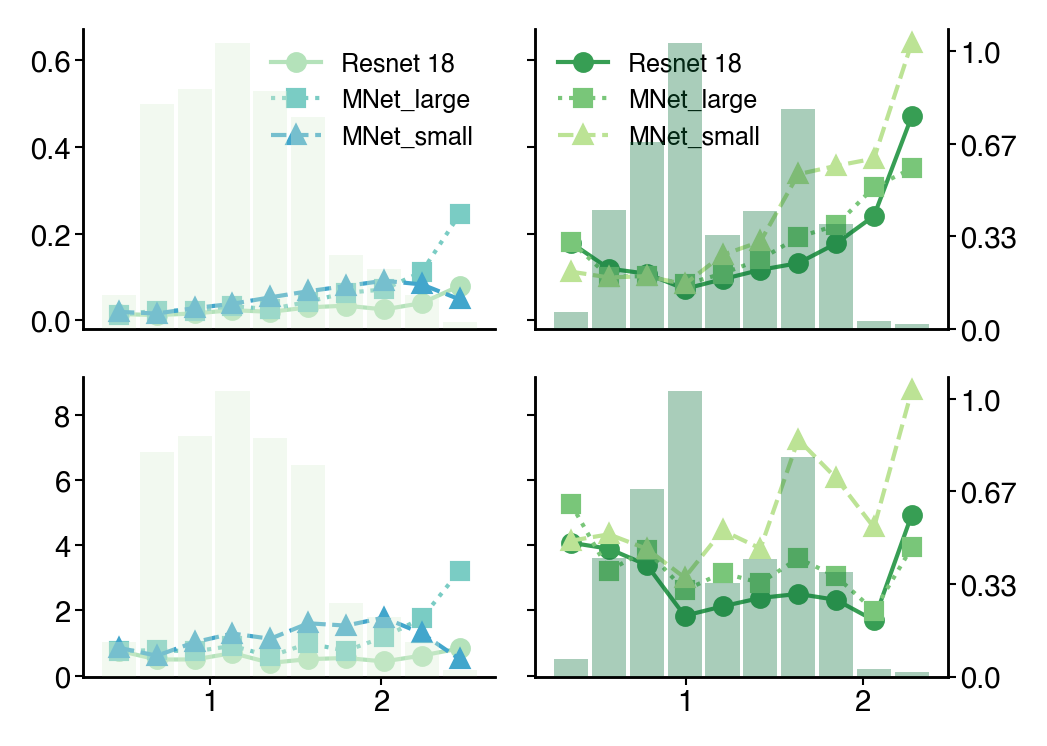

In [796]:
plt.style.use("~/Documents/paper.mplstyle")
import matplotlib.colors as mcolors


fig_size = (3.5, 2.5)
dpi = 300

n_color = 7

cmap = plt.cm.GnBu
colors_5 = [cmap(i/(n_color-1)) for i in range(n_color)]

cmap = plt.cm.YlGn_r
colors_7 = [cmap(i/(n_color-1)) for i in range(n_color)]

disable_mat = np.array([[True, True, False, False],
                        [False, True, False, True],
                        [True, False,True,False]])

plot_2x2_l2_vs_range([results_5, results_7, results_5, results_7],
                     [colors_5, colors_7, colors_5, colors_7],
                     disable_mat,
                     ['L2', 'L2', 'angle', 'angle'])

# stats = plot_l2_vs_range_multi(
#     detection_results,
#     nbins= 10,
#     plot_counts= True,
#     title= "L2 error vs. distance (5 cars)",
#     figsize=fig_size,
#     dpi= dpi,
#     plot_stat='L2',
#     save_path='/home/lab/Documents/picar/picar_ros2/training/eval/L2-dist-5.pdf',
#     colors=colors
# )

# stats = plot_l2_vs_range_multi(
#     detection_results,
#     nbins= 10,
#     plot_counts= True,
#     title= "Angle error vs. distance (5 cars)",
#     figsize=fig_size,
#     dpi= dpi,
#     plot_stat='angle',
#     with_legend=False,
#     save_path='/home/lab/Documents/picar/picar_ros2/training/eval/angle-dist-5.pdf',
#     colors=colors
# )


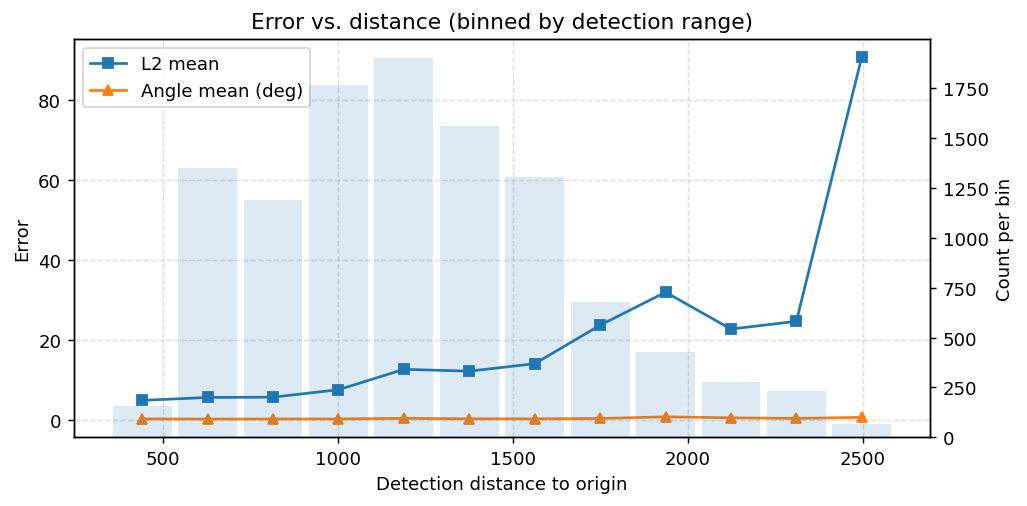

In [98]:
detections = values_tensor_all['pred']
labels = values_tensor_all['target']

stats = binned_errors_vs_range(
    detections, labels,
    nbins=12,   # or provide custom bin_edges=np.array([...])
    plot=True
)

In [628]:
eval_folders = ['/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S1',
                '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S2',
                '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S3',
                '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S4',
                # '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S5',
                '/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S7',]

test_dataset = pi_loader.PiCarDataset(
    roots=eval_folders,
    csv_glob="*.csv",
    transform=train_transform,          # we’ll override for val subset below
    target_transform=None,              # you can plug one in if needed
    strict=False,
    keep_last_n_levels=2, 
    max_time_diff=3e6,                 # e.g., 0.050 for 50 ms tolerance
    train=True
)

num_workers = 4
batch_size = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
    # collate_fn=smart_collate,
    drop_last=False
)

models = ['resnet18', 'mobilenet_v3_large', 'mobilenet_v3_small']
img_size = 128
out_folder = "onnx_models"
    
# for m in models:
#     print(f"Evaluating with {len(test_dataset)} images on {m} model")
#     onnx_model = create_onnx_session(f"{out_folder}/pi_vision_{m}_{img_size}.onnx")
#     output = evaluate_ds(onnx_model, test_loader, model_type="onnx")
    
for m in models:
    print(f"Evaluating with {len(test_dataset)} images on {m} model")
    torch_model = load_model_from_ckpt(f"/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_{m}.ckpt", backbone=m, out_agents=4)
    output = evaluate_ds(torch_model, test_loader, model_type="torch")
    

pose: 1.7563869423518817e+18, img: 1.756386942347098e+18
pair ts diff to large
pose: 1.7563869423518817e+18, img: 1.756386942347098e+18
pair ts diff to large
pose: 1.7563869430285501e+18, img: 1.7563869430327268e+18
pair ts diff to large
pose: 1.7563869431285504e+18, img: 1.7563869431328568e+18
pair ts diff to large
pose: 1.7563869431285504e+18, img: 1.7563869431328568e+18
pair ts diff to large
pose: 1.7563869431585503e+18, img: 1.7563869431659118e+18
pair ts diff to large
pose: 1.7563869432285501e+18, img: 1.7563869432326328e+18
pair ts diff to large
pose: 1.7563869433285504e+18, img: 1.7563869433325763e+18
pair ts diff to large
pose: 1.7563869434385503e+18, img: 1.7563869434339e+18
pair ts diff to large
pose: 1.7563869435285504e+18, img: 1.7563869435322483e+18
pair ts diff to large
pose: 1.7563869435685504e+18, img: 1.7563869435655e+18
pair ts diff to large
pose: 1.7563869436685501e+18, img: 1.7563869436653885e+18
pair ts diff to large
pose: 1.7563869438685501e+18, img: 1.75638694386

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


{'true positive': 2198, 'false positive': 92, 'false negative': 18, 'true negative': 567}
{'L1': tensor(135.5205), 'L2': tensor(106.8792), 'angle': tensor(2.4724)}
Evaluating with 2875 images on mobilenet_v3_large model
{'true positive': 2148, 'false positive': 142, 'false negative': 13, 'true negative': 572}
{'L1': tensor(158.9864), 'L2': tensor(124.9973), 'angle': tensor(3.0503)}
Evaluating with 2875 images on mobilenet_v3_small model
{'true positive': 2126, 'false positive': 164, 'false negative': 29, 'true negative': 556}
{'L1': tensor(173.3924), 'L2': tensor(134.2286), 'angle': tensor(4.0265)}


In [20]:
exp30_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S1',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S2',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S3']

evaluate_folders(trained_model, exp30_folder)

{'true positive': 978, 'false positive': 139, 'false negative': 15, 'true negative': 444}
{'L1': tensor(89.7153), 'L2': tensor(70.9512), 'angle': tensor(1.5580)}


({'true positive': 978,
  'false positive': 139,
  'false negative': 15,
  'true negative': 444},
 {'L1': tensor(89.7153), 'L2': tensor(70.9512), 'angle': tensor(1.5580)},
 {'pred': [tensor([[ 577.1285, -185.1540,    3.3814]]),
   tensor([[ 579.0493, -195.5242,    3.0501]]),
   tensor([[ 570.4741, -216.8682,    2.9140]]),
   tensor([[ 544.8738, -224.6118,    3.3578]]),
   tensor([[ 527.7598, -238.7480,    4.2869]]),
   tensor([[ 519.4637, -261.8704,    4.4755]]),
   tensor([[ 497.3831, -317.1590,    2.1354]]),
   tensor([[1.1172e+03, 1.9869e+02, 6.4029e-01]]),
   tensor([[1.1413e+03, 1.1415e+02, 7.5119e-01]]),
   tensor([[1.1698e+03, 2.2413e+01, 5.9712e-01]]),
   tensor([[1210.2251, -124.9829,    2.0412]]),
   tensor([[1205.1885, -213.1835,    1.4923]]),
   tensor([[1171.6433, -369.9760,    5.7895]]),
   tensor([[ 983.5430, -596.4691,    3.4460]]),
   tensor([[1014.5779, -521.3464,    6.0655]]),
   tensor([[1039.3545, -429.8060,    6.0792]]),
   tensor([[1072.6228, -343.4576,    5.7959

In [105]:
exp60_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_exp60/2025_0819_1102-S1',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp60/2025_0819_1102-S2',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp60/2025_0819_1102-S3']

evaluate_folders(trained_model, exp60_folder)

{'true positive': 1390, 'false positive': 19, 'false negative': 18, 'true negative': 613}
{'L1': tensor(63.3949), 'L2': tensor(51.3262), 'angle': tensor(0.9680)}


({'true positive': 1390,
  'false positive': 19,
  'false negative': 18,
  'true negative': 613},
 {'L1': tensor(63.3949), 'L2': tensor(51.3262), 'angle': tensor(0.9680)})

In [106]:
exp90_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_exp90/2025_0819_1109-S1',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp90/2025_0819_1109-S2',
                '/home/lab/Documents/picar/2025_train_data/test_set_exp90/2025_0819_1109-S3']

evaluate_folders(trained_model, exp90_folder)

{'true positive': 1853, 'false positive': 37, 'false negative': 25, 'true negative': 905}
{'L1': tensor(54.1016), 'L2': tensor(42.9980), 'angle': tensor(0.8709)}


({'true positive': 1853,
  'false positive': 37,
  'false negative': 25,
  'true negative': 905},
 {'L1': tensor(54.1016), 'L2': tensor(42.9980), 'angle': tensor(0.8709)})

## demo from top-down view

In [3]:
demo_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S1',
                # '/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S2',
                # '/home/lab/Documents/picar/2025_train_data/test_set_exp30/2025_0819_1055-S3'
                ]

# --- transforms (adjust size to your backbone) ---
IMG_SIZE = (224, 224)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- dataset construction ---
# IMPORTANT: set your paths and timestamp column names if different
demo_dataset = pi_loader.PiCarDataset(
    roots=demo_folder,
    csv_glob="*.csv",
    transform=train_transform,          # we’ll override for val subset below
    target_transform=None,              # you can plug one in if needed
    strict=False,
    keep_last_n_levels=2, 
    max_time_diff=None                  # e.g., 0.050 for 50 ms tolerance
)

print(demo_dataset[0])

(tensor([[[-0.4911, -0.5767, -0.6281,  ..., -0.2513, -0.2513,  0.3138],
         [-0.4739, -0.5767, -0.6281,  ..., -0.2513, -0.2684,  0.2967],
         [-0.4739, -0.5767, -0.5938,  ..., -0.2513, -0.2684,  0.2796],
         ...,
         [-1.2445, -1.1760, -1.1589,  ..., -1.2617, -1.3130, -0.4911],
         [-1.1760, -1.1418, -1.1075,  ..., -1.2103, -1.2445, -0.4739],
         [-1.0219, -1.0219, -0.9877,  ..., -1.0904, -1.1589, -0.4397]],

        [[-0.1450, -0.2500, -0.3375,  ...,  0.0651,  0.0651,  0.4853],
         [-0.1625, -0.2850, -0.3550,  ...,  0.0826,  0.0826,  0.4853],
         [-0.1800, -0.2850, -0.3550,  ...,  0.1001,  0.1001,  0.4853],
         ...,
         [-0.8627, -0.8277, -0.8277,  ..., -0.9153, -0.9153, -0.2850],
         [-0.8452, -0.8277, -0.8452,  ..., -0.9853, -0.9503, -0.3025],
         [-0.7927, -0.8102, -0.8452,  ..., -0.9678, -0.9153, -0.3025]],

        [[-0.0790, -0.1487, -0.2184,  ...,  0.1302,  0.1302,  0.4614],
         [-0.0790, -0.1661, -0.2184,  ...,  

In [5]:
import re
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from tqdm import tqdm

import dataloader as pi_loader

from torchvision import transforms

from network import PiVisionNet


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm_imagenet(img_chw: torch.Tensor) -> np.ndarray:
    """
    img_chw: torch.Tensor (C,H,W), ImageNet normalized
    returns: np.uint8 (H,W,3) in [0,255]
    """
    if img_chw.ndim != 3:
        raise ValueError("Expected CHW tensor for image.")
    x = img_chw.detach().cpu()
    x = (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)
    x = (x.permute(1,2,0).numpy() * 255.0).round().astype(np.uint8)
    return x

def parse_label_agents(label: dict):
    """
    Extracts self pose and agent poses from label dict.
    Returns:
      self_pose: (x, y, angle_deg)
      agents: list of dicts {id, x, y, angle_deg}
    """
    # Self
    try:
        self_x = float(label['self_pose_x'])
        self_y = float(label['self_pose_y'])
        self_ang = float(label['self_pose_angle'])
        self_pose = (self_x, self_y, self_ang)
    except KeyError as e:
        raise KeyError(f"Missing self pose key in label: {e}")

    # Agents
    agents = {}
    pat = re.compile(r"^(?P<prefix>.+)_pose_(?P<field>x|y|angle)$")
    for k, v in label.items():
        m = pat.match(k)
        if not m: 
            continue
        prefix = m.group("prefix")
        field = m.group("field")
        if prefix == "self":  # already handled
            continue
        agents.setdefault(prefix, {})[field] = float(v)

    out = []
    for prefix, d in agents.items():
        if all(f in d for f in ("x", "y", "angle")):
            # Try to shorten label e.g. "car_S2" -> "S2"
            short_id = prefix
            m = re.match(r".*_(\w+)$", prefix)
            if m:
                short_id = m.group(1)
            out.append({"id": short_id, "x": d["x"], "y": d["y"], "angle_deg": d["angle"]})
    return self_pose, out

def rotate_translate_points(rel_xy: np.ndarray, origin_xy: tuple, angle_deg: float) -> np.ndarray:
    """
    Convert points in self-frame to world frame:
      world_xy = R(angle_deg) @ rel_xy + origin
    rel_xy: (N,2), origin_xy: (x0, y0)
    """
    if rel_xy.size == 0:
        return rel_xy
    theta = math.radians(angle_deg)
    c, s = math.cos(theta), math.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]], dtype=np.float32)
    world = rel_xy @ R.T
    world[:,0] += origin_xy[0]
    world[:,1] += origin_xy[1]
    return world

def arrows_from_pose(ax, x, y, angle_deg, length=80.0, **kwargs):
    """Draw a heading arrow at (x,y) pointing along angle_deg."""
    theta = math.radians(angle_deg)
    dx, dy = length*math.cos(theta), length*math.sin(theta)
    ax.arrow(x, y, dx, dy, head_width=length*0.25, head_length=length*0.35, length_includes_head=True, **kwargs)

def get_sample(dataset, idx):
    """Support (img, label) or dict styles."""
    sample = dataset[idx]
    if isinstance(sample, tuple) and len(sample) == 2:
        img, label = sample
    elif isinstance(sample, dict):
        img = sample.get("image", sample.get("img", None))
        label = sample.get("label", sample)
        if img is None:
            raise ValueError("Could not find 'image' key in dict sample.")
    else:
        raise ValueError("Dataset __getitem__ must return (image, label_dict) or a dict.")
    if not isinstance(label, dict):
        raise ValueError("Label must be a dict containing pose fields.")
    return img, label

def _ray_endpoint_to_axes(ax, x0, y0, angle_deg):
    """
    From (x0,y0), cast a ray at angle_deg and return its intersection with ax's
    current rectangular limits. Returns (x1, y1).
    """
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    th = math.radians(angle_deg)
    c, s = math.cos(th), math.sin(th)

    # Parametric ray: x = x0 + t*c, y = y0 + t*s, t >= 0
    candidates = []

    # Intersect with verticals x = xmin/xmax
    if abs(c) > 1e-12:
        t = (xmin - x0) / c
        if t >= 0:
            y = y0 + t*s
            if ymin - 1e-9 <= y <= ymax + 1e-9:
                candidates.append((t, xmin, y))
        t = (xmax - x0) / c
        if t >= 0:
            y = y0 + t*s
            if ymin - 1e-9 <= y <= ymax + 1e-9:
                candidates.append((t, xmax, y))

    # Intersect with horizontals y = ymin/ymax
    if abs(s) > 1e-12:
        t = (ymin - y0) / s
        if t >= 0:
            x = x0 + t*c
            if xmin - 1e-9 <= x <= xmax + 1e-9:
                candidates.append((t, x, ymin))
        t = (ymax - y0) / s
        if t >= 0:
            x = x0 + t*c
            if xmin - 1e-9 <= x <= xmax + 1e-9:
                candidates.append((t, x, ymax))

    if not candidates:
        # Fallback: extend a long segment if something degenerate happens
        L = max(xmax - xmin, ymax - ymin) * 2.0
        return (x0 + L*c, y0 + L*s)

    # Pick the nearest positive intersection
    _, x1, y1 = min(candidates, key=lambda tup: tup[0])
    return x1, y1

def _draw_fov_rays(ax, x0, y0, facing_deg, delta_deg=30.0, **plot_kw):
    """
    Draw two rays from (x0,y0) at facing ± delta_deg to the axes bounds.
    """
    for sign in (+1, -1):
        ang = facing_deg + sign * delta_deg
        x1, y1 = _ray_endpoint_to_axes(ax, x0, y0, ang)
        ax.plot([x0, x1], [y0, y1], **plot_kw)


@torch.no_grad()
def make_video(dataset,
               trained_model,
               output_mp4="output.mp4",
               fps=5,
               device=None,
               conf_thresh=0.5,
               arrow_len=80.0,
               point_size=30.0,
               max_frames=None):
    """
    Iterate dataset, run model, render side-by-side (image / world map), and save MP4.
    """
    trained_model.eval()
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    trained_model.to(device)

    # Prepare figure
    plt.ioff()
    fig = plt.figure(figsize=(10, 5), dpi=150)
    gs = fig.add_gridspec(1, 2, width_ratios=[1,1.2])
    ax_img = fig.add_subplot(gs[0,0])
    ax_map = fig.add_subplot(gs[0,1])

    writer = FFMpegWriter(fps=fps, bitrate=1800, codec='mpeg4')

    n_total = len(dataset) if max_frames is None else min(max_frames, len(dataset))

    with writer.saving(fig, output_mp4, dpi=150):
        for idx in tqdm(range(n_total), desc="Rendering"):
            # --- Get data
            image_chw, label = get_sample(dataset, idx)
            if isinstance(image_chw, np.ndarray):
                image_chw = torch.from_numpy(image_chw)
            image_chw = image_chw.float()
            # Keep original normalized tensor for model; denorm for display later
            disp_hw3 = denorm_imagenet(image_chw)

            # --- Poses
            self_pose, agents = parse_label_agents(label)
            self_x, self_y, self_ang = self_pose

            # --- Model prediction (relative to self)
            model_in = image_chw.unsqueeze(0).to(device)      # [1,C,H,W]
            pred = trained_model(model_in)                    # expect [1,N,3] or [N,3]
            if pred.ndim == 3:
                pred = pred[0]
            pred = pred.detach().cpu().float().numpy()        # (N,3)
            if pred.size == 0:
                pred_rel = np.zeros((0,2), dtype=np.float32)
            else:
                conf = pred[:,2]
                keep = conf >= conf_thresh
                pred_rel = pred[keep, :2]

            # --- Convert predictions to world frame
            pred_world = rotate_translate_points(pred_rel, (self_x, self_y), self_ang)

            # --- Prepare map data
            # Collect ground-truth agent/world points for bounds
            gt_pts = [(self_x, self_y)]
            gt_pts += [(a["x"], a["y"]) for a in agents]
            gt_pts = np.array(gt_pts, dtype=np.float32)

            all_x = [gt_pts[:,0].min(), gt_pts[:,0].max()] if gt_pts.size else []
            all_y = [gt_pts[:,1].min(), gt_pts[:,1].max()] if gt_pts.size else []
            if pred_world.size:
                all_x += [pred_world[:,0].min(), pred_world[:,0].max()]
                all_y += [pred_world[:,1].min(), pred_world[:,1].max()]

            if all_x and all_y:
                xmin, xmax = min(all_x), max(all_x)
                ymin, ymax = min(all_y), max(all_y)
                margin = 0.15 * max(1.0, max(xmax - xmin, ymax - ymin))
                xmin, xmax = xmin - margin, xmax + margin
                ymin, ymax = ymin - margin, ymax + margin
            else:
                # Fallback window around self
                xmin, xmax = self_x - 300, self_x + 300
                ymin, ymax = self_y - 300, self_y + 300

            # --- Draw left image
            ax_img.clear()
            ax_img.imshow(disp_hw3)
            ax_img.set_title(f"Frame {idx}")
            ax_img.axis("off")

            # --- Draw right world map
            ax_map.clear()
            ax_map.set_aspect("equal", adjustable="box")

            # 🔒 fixed limits instead of auto zoom
            ax_map.set_xlim(-1400, 1400)
            ax_map.set_ylim(-1400, 1400)

            ax_map.grid(True, linestyle="--", alpha=0.3)
            ax_map.set_title("World positions (GT agents + predicted targets)")

            # Plot self
            ax_map.scatter([self_x], [self_y], s=point_size*1.5, marker="o", label="self")
            arrows_from_pose(ax_map, self_x, self_y, self_ang, length=arrow_len, alpha=0.8)
            
            # >>> Add ±30° rays relative to self's facing <<<
            # Make sure limits are already set before computing intersections:
            # (you already set fixed limits to [-1400, 1400] above)
            _draw_fov_rays(
                ax_map, self_x, self_y, self_ang, delta_deg=30.0,
                linewidth=0.5, linestyle="-.", alpha=0.8, color='red'
            )           

            # Plot agents (GT)
            if agents:
                ax_map.scatter(
                    [a["x"] for a in agents],
                    [a["y"] for a in agents],
                    s=point_size, marker="o", label="agents (GT)"
                )
                for a in agents:
                    arrows_from_pose(ax_map, a["x"], a["y"], a["angle_deg"], length=arrow_len*0.9, alpha=0.8)
                    ax_map.text(a["x"], a["y"], f"{a['id']}", fontsize=8, ha="left", va="bottom")

            # Plot predictions (rotated into world)
            if pred_world.size:
                ax_map.scatter(pred_world[:,0], pred_world[:,1], s=point_size, marker="x", label="predicted (world)")

                # 🟢 draw connecting lines from self to each detected position
                for (px, py) in pred_world:
                    ax_map.plot([self_x, px], [self_y, py], "r--", linewidth=1, alpha=0.7)

            ax_map.legend(loc="upper right", fontsize=8, frameon=True)

            # --- Write frame
            writer.grab_frame()

    print(f"✅ Saved video to: {output_mp4}")

In [22]:
trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best.ckpt")

make_video(demo_dataset, trained_model)

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Rendering: 100%|██████████| 480/480 [00:32<00:00, 14.65it/s]

✅ Saved video to: output.mp4


### Kalman tracking

In [56]:
import numpy as np
from scipy.optimize import linear_sum_assignment

CHI2_GATE_2D = 9.21  #5.991  # ~95% for 2 DoF

class KalmanCV2D:
    def __init__(self, x0, P0=None, sigma_a=1.0, R=np.diag([9.0, 9.0])):
        self.x = x0.copy()  # [x,y,vx,vy]
        self.P = np.eye(4)*100 if P0 is None else P0.copy()
        self.sigma_a = sigma_a
        self.R = R

    def predict(self, dt, ego_vel=None):
        F = np.array([[1,0,dt,0],
                      [0,1,0,dt],
                      [0,0,1,0],
                      [0,0,0,1]], dtype=float)
        G = np.array([[0.5*dt**2, 0],
                      [0, 0.5*dt**2],
                      [dt, 0],
                      [0, dt]], dtype=float)
        Q = (self.sigma_a**2) * (G @ G.T)

        u = np.zeros(2)
        if ego_vel is not None:
            # subtract camera motion to keep state stable in ego frame
            u = np.asarray(ego_vel, dtype=float)

        B = np.array([[dt,0],
                      [0,dt],
                      [0,0],
                      [0,0]], dtype=float)

        self.x = F @ self.x - B @ u
        self.P = F @ self.P @ F.T + Q

    def innovation(self, z):
        H = np.array([[1,0,0,0],
                      [0,1,0,0]], dtype=float)
        y = z - (H @ self.x)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        return y, S, K, H

    def update(self, z):
        y, S, K, H = self.innovation(z)
        self.x = self.x + K @ y
        I = np.eye(4)
        self.P = (I - K @ H) @ self.P

    def maha(self, z):
        y, S, _, _ = self.innovation(z)
        return float(y.T @ np.linalg.inv(S) @ y)

class Track:
    _next_id = 0
    def __init__(self, z0, dt, ego_vel, R, sigma_a=1.0):
        x0 = np.array([z0[0], z0[1], 0.0, 0.0], dtype=float)
        self.kf = KalmanCV2D(x0, R=R, sigma_a=sigma_a)
        self.kf.predict(dt, ego_vel)  # prime velocity from first step
        self.id = Track._next_id; Track._next_id += 1
        self.hits = 1
        self.misses = 0

    def predict(self, dt, ego_vel):
        self.kf.predict(dt, ego_vel)

    def update(self, z):
        self.kf.update(z)
        self.hits += 1
        self.misses = 0

INF = 1e9 
def associate(tracks, detections, dt,
              max_maha2=CHI2_GATE_2D,           # 99% chi^2 for 2D
              max_euclid_mm=400.0,      # hard spatial gate (set None to disable)
              max_speed_mm_s=300.0,     # kinematic gate (set None to disable)
              k_sigma=2.5               # extra allowance from covariance
             ):
    """
    tracks: list of Track objects (each has kf with x=[x,y,vx,vy], P)
    detections: list of np.array([x,y]) in mm (already FOV-gated)
    dt: seconds since last frame
    returns: matches [(track_idx, det_idx)], unmatched_tracks, unmatched_dets
    """
    if not tracks or not detections:
        return [], list(range(len(tracks))), list(range(len(detections)))

    T, D = len(tracks), len(detections)
    cost = np.full((T, D), INF, dtype=float)

    for i, trk in enumerate(tracks):
        # Predicted position mean and variance (pos block of P)
        x = trk.kf.x
        P = trk.kf.P
        p_pred = x[:2]
        P_pos = P[:2, :2]
        # Pos std for adaptive padding (ellipse -> use largest std)
        sigma_pos = float(np.sqrt(max(P_pos[0,0], P_pos[1,1])))

        # Max allowed travel distance this frame from kinematics
        if max_speed_mm_s is not None:
            d_kin = max_speed_mm_s * dt + k_sigma * sigma_pos
        else:
            d_kin = None

        for j, z in enumerate(detections):
            # 1) Mahalanobis gate (statistical)
            d2 = trk.kf.maha(z)
            if d2 > max_maha2:
                continue  # reject

            # 2) Euclidean gate (metric)
            if max_euclid_mm is not None:
                de = float(np.linalg.norm(z - p_pred))
                if de > max_euclid_mm:
                    continue  # reject

            # 3) Kinematic gate (speed bound)
            if d_kin is not None:
                if de > d_kin:
                    continue  # reject

            # Passed all gates → set cost (use Mahalanobis as cost)
            cost[i, j] = d2

    rows, cols = linear_sum_assignment(cost)
    matches, unmatched_tracks, unmatched_dets = [], set(range(T)), set(range(D))
    for r, c in zip(rows, cols):
        if cost[r, c] < INF:
            matches.append((r, c))
            unmatched_tracks.discard(r)
            unmatched_dets.discard(c)

    return matches, sorted(unmatched_tracks), sorted(unmatched_dets)

# def associate(tracks, detections, gate=CHI2_GATE_2D):
#     if not tracks or not detections:
#         return [], list(range(len(tracks))), list(range(len(detections)))
#     cost = np.full((len(tracks), len(detections)), fill_value=1e6, dtype=float)
#     for i, trk in enumerate(tracks):
#         for j, z in enumerate(detections):
#             d2 = trk.kf.maha(z)
#             if d2 <= gate:
#                 cost[i, j] = d2
#     rows, cols = linear_sum_assignment(cost)
#     matches, u_trk, u_det = [], set(range(len(tracks))), set(range(len(detections)))
#     for r, c in zip(rows, cols):
#         if cost[r, c] < 1e5:
#             matches.append((r, c))
#             u_trk.discard(r); u_det.discard(c)
#     return matches, sorted(u_trk), sorted(u_det)

class MultiTracker:
    def __init__(self, R=np.diag([9.0, 9.0]), sigma_a=1.0,
                 max_misses=10, min_hits=2, fov_deg=70.0):
        self.tracks = []
        self.R = R
        self.sigma_a = sigma_a
        self.max_misses = max_misses
        self.min_hits = min_hits
        self.fov_rad = np.deg2rad(fov_deg/2)

    def in_fov(self, z):
        # gate by ±(fov/2) around +x axis (camera forward)
        angle = np.arctan2(z[1], z[0])
        return -self.fov_rad <= angle <= self.fov_rad

    def step(self, detections_cam, dt, ego_vel_cam=(0.0, 0.0)):
        # FOV-gate detections
        dets = [np.asarray(d, float) for d in detections_cam if self.in_fov(d)]

        # Predict all tracks with ego motion compensation
        for trk in self.tracks:
            trk.predict(dt, ego_vel_cam)

        # Associate
        matches, u_trk, u_det = associate(self.tracks, dets, dt)

        # Update matched
        for ti, di in matches:
            self.tracks[ti].update(dets[di])

        # Create new tracks for unmatched detections
        for di in u_det:
            self.tracks.append(Track(dets[di], dt, ego_vel_cam, self.R, self.sigma_a))

        # Age unmatched tracks
        survivors = []
        for idx, trk in enumerate(self.tracks):
            if idx in u_trk:
                trk.misses += 1
            if trk.misses <= self.max_misses:
                survivors.append(trk)
        self.tracks = survivors

        # Output current estimates (only confirmed if desired)
        outputs = []
        for trk in self.tracks:
            x = trk.kf.x
            confirmed = trk.hits >= self.min_hits
            outputs.append({
                "id": trk.id, "x": x[0], "y": x[1], "vx": x[2], "vy": x[3],
                "confirmed": confirmed, "misses": trk.misses, "hits": trk.hits
            })
        return outputs


In [57]:
@torch.no_grad()
def make_filtered_video(dataset,
                        trained_model,
                        output_mp4="filtered_output.mp4",
                        fps=5,
                        device=None,
                        conf_thresh=0.5,
                        arrow_len=80.0,
                        point_size=30.0,
                        max_frames=None):
    """
    Iterate dataset, run model, render side-by-side (image / world map), and save MP4.
    """
    trained_model.eval()
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    trained_model.to(device)

    # Prepare figure
    plt.ioff()
    fig = plt.figure(figsize=(10, 5), dpi=150)
    gs = fig.add_gridspec(1, 2, width_ratios=[1,1.2])
    ax_img = fig.add_subplot(gs[0,0])
    ax_map = fig.add_subplot(gs[0,1])

    writer = FFMpegWriter(fps=fps, bitrate=1800, codec='mpeg4')

    n_total = len(dataset) if max_frames is None else min(max_frames, len(dataset))
    
    prev_img_ts = None

    with writer.saving(fig, output_mp4, dpi=150):
        for idx in tqdm(range(n_total), desc="Rendering"):
            # --- Get data
            image_chw, label = get_sample(dataset, idx)
            if isinstance(image_chw, np.ndarray):
                image_chw = torch.from_numpy(image_chw)
            image_chw = image_chw.float()
            # Keep original normalized tensor for model; denorm for display later
            disp_hw3 = denorm_imagenet(image_chw)

            # --- Poses
            self_pose, agents = parse_label_agents(label)
            self_x, self_y, self_ang = self_pose

            # --- Model prediction (relative to self)
            model_in = image_chw.unsqueeze(0).to(device)      # [1,C,H,W]
            pred = trained_model(model_in)                    # expect [1,N,3] or [N,3]
            if pred.ndim == 3:
                pred = pred[0]
            pred = pred.detach().cpu().float().numpy()        # (N,3)
            if pred.size == 0:
                pred_rel = np.zeros((0,2), dtype=np.float32)
            else:
                conf = pred[:,2]
                keep = conf >= conf_thresh
                pred_rel = pred[keep, :2]
                
            # --- post process with Kalman filter
            if idx==0:
                tracker = MultiTracker(R=np.diag([90, 90]), sigma_a=20, min_hits=4, max_misses=2, fov_deg=65)
                prev_img_ts = label['image_timestamp']
            else:
                dt = (label['image_timestamp'] - prev_img_ts) / 1e9
                tracked = tracker.step(pred_rel, dt)
                
                current_frame_tracklets = []
                for tk in tracked:
                    if tk['confirmed']:
                        current_frame_tracklets.append([tk['x'], tk['y']])
                        
                pred_rel_filter = np.array(current_frame_tracklets)
                pred_world_filter = rotate_translate_points(pred_rel_filter, (self_x, self_y), self_ang)

            # --- Convert predictions to world frame
            pred_world = rotate_translate_points(pred_rel, (self_x, self_y), self_ang)
            

            # --- Prepare map data
            # Collect ground-truth agent/world points for bounds
            gt_pts = [(self_x, self_y)]
            gt_pts += [(a["x"], a["y"]) for a in agents]
            gt_pts = np.array(gt_pts, dtype=np.float32)

            all_x = [gt_pts[:,0].min(), gt_pts[:,0].max()] if gt_pts.size else []
            all_y = [gt_pts[:,1].min(), gt_pts[:,1].max()] if gt_pts.size else []
            if pred_world.size:
                all_x += [pred_world[:,0].min(), pred_world[:,0].max()]
                all_y += [pred_world[:,1].min(), pred_world[:,1].max()]

            if all_x and all_y:
                xmin, xmax = min(all_x), max(all_x)
                ymin, ymax = min(all_y), max(all_y)
                margin = 0.15 * max(1.0, max(xmax - xmin, ymax - ymin))
                xmin, xmax = xmin - margin, xmax + margin
                ymin, ymax = ymin - margin, ymax + margin
            else:
                # Fallback window around self
                xmin, xmax = self_x - 300, self_x + 300
                ymin, ymax = self_y - 300, self_y + 300

            # --- Draw left image
            ax_img.clear()
            ax_img.imshow(disp_hw3)
            ax_img.set_title(f"Frame {idx}")
            ax_img.axis("off")

            # --- Draw right world map
            ax_map.clear()
            ax_map.set_aspect("equal", adjustable="box")

            # 🔒 fixed limits instead of auto zoom
            ax_map.set_xlim(-1400, 1400)
            ax_map.set_ylim(-1400, 1400)

            ax_map.grid(True, linestyle="--", alpha=0.3)
            ax_map.set_title("World positions (GT agents + predicted targets)")

            # Plot self
            ax_map.scatter([self_x], [self_y], s=point_size*1.5, marker="o", label="self")
            arrows_from_pose(ax_map, self_x, self_y, self_ang, length=arrow_len, alpha=0.8)
            
            # >>> Add ±30° rays relative to self's facing <<<
            # Make sure limits are already set before computing intersections:
            # (you already set fixed limits to [-1400, 1400] above)
            _draw_fov_rays(
                ax_map, self_x, self_y, self_ang, delta_deg=30.0,
                linewidth=0.5, linestyle="-.", alpha=0.8, color='red'
            )           

            # Plot agents (GT)
            if agents:
                ax_map.scatter(
                    [a["x"] for a in agents],
                    [a["y"] for a in agents],
                    s=point_size, marker="o", label="agents (GT)"
                )
                for a in agents:
                    arrows_from_pose(ax_map, a["x"], a["y"], a["angle_deg"], length=arrow_len*0.9, alpha=0.8)
                    ax_map.text(a["x"], a["y"], f"{a['id']}", fontsize=8, ha="left", va="bottom")

            # Plot predictions (rotated into world)
            if pred_world.size:
                ax_map.scatter(pred_world[:,0], pred_world[:,1], s=point_size, marker="x", label="predicted", color='red', alpha=0.6)
                
                # 🟢 draw connecting lines from self to each detected position
                for (px, py) in pred_world:
                    ax_map.plot([self_x, px], [self_y, py], "r--", linewidth=1, color='yellow', alpha=0.6)
                    
            if idx > 0:
                if pred_world_filter.size:
                    ax_map.scatter(pred_world_filter[:,0], pred_world_filter[:,1], s=point_size, marker="x", label="predicted (filtered)")
                    for (px, py) in pred_world_filter:
                        ax_map.plot([self_x, px], [self_y, py], "r--", linewidth=1, alpha=0.7)

            ax_map.legend(loc="upper right", fontsize=8, frameon=True)

            # --- Write frame
            writer.grab_frame()

    print(f"✅ Saved video to: {output_mp4}")

In [26]:
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_small.ckpt", backbone="mobilenetv3_small", out_agents=4)
# trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_mobilenet_v3_large.ckpt", backbone="mobilenetv3_large", out_agents=4)
trained_model = load_model_from_ckpt("/home/lab/Documents/picar/picar_ros2/training/checkpoints/best_resnet18.ckpt", backbone="resnet18", out_agents=4)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# --- dataset construction ---
demo_folder = ['/home/lab/Documents/picar/2025_train_data/test_set_7cars/2025_0828_1519-S4']

demo_dataset = pi_loader.PiCarDataset(
    roots=demo_folder,
    csv_glob="*.csv",
    transform=train_transform,          # we’ll override for val subset below
    target_transform=None,              # you can plug one in if needed
    strict=False,
    keep_last_n_levels=2, 
    max_time_diff=3e6,                 # e.g., 0.050 for 50 ms tolerance
    train=False
)
print(len(demo_dataset))

/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lab/anaconda3/envs/py310-cuda12/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


pose: 1.7563869388362452e+18, img: 1.7563869388286953e+18
pair ts diff to large
pose: 1.7563869519162452e+18, img: 1.756386951923015e+18
pair ts diff to large
pose: 1.7563869557262454e+18, img: 1.7563869557210255e+18
pair ts diff to large
pose: 1.7563869668062454e+18, img: 1.756386966814103e+18
pair ts diff to large
pose: 1.756386970706245e+18, img: 1.7563869707133169e+18
pair ts diff to large
pose: 1.7563869749362452e+18, img: 1.756386974943007e+18
pair ts diff to large
pose: 1.7563869777262454e+18, img: 1.7563869776079268e+18
pair ts diff to large
pose: 1.7563869777262454e+18, img: 1.7563869776746458e+18
pair ts diff to large
pose: 1.7563869777262454e+18, img: 1.756386977709255e+18
pair ts diff to large
pose: 1.7563869777662454e+18, img: 1.7563869777745254e+18
pair ts diff to large
pose: 1.7563869823762452e+18, img: 1.7563869822394831e+18
pair ts diff to large
pose: 1.7563869823762452e+18, img: 1.7563869823055176e+18
pair ts diff to large
pose: 1.7563869823762452e+18, img: 1.75638698

In [58]:
make_filtered_video(demo_dataset, trained_model)

Rendering:   0%|          | 0/1436 [00:00<?, ?it/s]

/tmp/ipykernel_151632/2010056679.py:148: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax_map.plot([self_x, px], [self_y, py], "r--", linewidth=1, color='yellow', alpha=0.6)
Rendering: 100%|██████████| 1436/1436 [01:40<00:00, 14.24it/s]

✅ Saved video to: filtered_output.mp4


In [19]:
(1.7563870075962452e+18 - 1.756387007526883e+18) / 1e9

0.069362176